## Single perspective optimziation across futures, type 2 Regret

#### Using v3.3 + Type-2 Regret (overview)

- **Goal.** For each narrative (e.g., _IndustryEnergyInvestment_, _EmissionsReduction_, _PlaceToLive_), find **one representative policy** that performs well across many possible futures using **Type-2 regret** (percentile-of-regret across futures; lower is better).

- **Inputs.**
  - A trained XGBoost pipeline (`trained_models/xgb_pipeline_5.4.pkl`) and its training DataFrame (`xgb_pipeline_5.4_training_df.parquet`).
  - The model’s metric order (`train_metrics`) including emissions, production, costs, air pollution, and jobs metrics.

- **Futures (exogenous scenarios).**
  - Columns named like `group_<N>` with `N ≥ 46` are treated as **exogenous** (fixed per future).
  - Unique combinations of these columns in the training data define the **set of futures** used for evaluation.

- **Decision variables.**
  - All feature columns **excluding** the exogenous `group_≥46` columns are treated as **free (optimizable) levers**.

- **Optimization (per narrative).**
  - Calls `optimise_aggregated_over_futures(..., agg_mode="regret2")`.
  - For the narrative’s objectives (min/max per metric), the optimizer minimizes **Type-2 regret**:
    - For each candidate policy, compute regret in every future (normalized by range or best).
    - Take the chosen **percentile** across futures (e.g., 75th) per metric.
    - Return the set of **non-dominated candidates** in regret space (a Pareto set for that narrative).

- **Pick one policy per narrative.**
  - Aggregate each candidate’s per-metric Type-2 regrets (default = **mean**; options include **max** or **L2**).
  - Select the **single** lowest-aggregate-regret policy for that narrative.

- **Cross-evaluation matrix.**
  - Evaluate the selected policies **as if** each narrative’s objectives were the goal.
  - Report the **Type-2 regret** (percentile across futures, normalized) for each \[policy × evaluated-as\] pair.
  - The diagonal (self-evaluation) is hidden for readability.

- **Two-other-narratives summary.**
  - For each selected policy, compute the **mean** and **worst** Type-2 regret **only in the other narratives**.
  - Highlight the lowest (best) values to show which policy generalizes most robustly.

- **Key knobs.**
  - `REGRET_PERCENTILE` (e.g., 75 or 90) — how conservative the cross-futures summary is.
  - `REGRET_NORM` = `"range"` (default) or `"best"` — normalization used in regret.
  - Selection aggregator across metrics: `"mean"` (default), `"max"` (stricter), or `"l2"`.

- **Assumptions & requirements.**
  - `air_pollution` is treated as a **benefit** (maximize);
  - Requires `utils/narrative_profiles_optimization_utils.py` **v3.3 with regret2** API.
  - Multi-threaded prediction is enabled when supported by the estimator.


In [1]:
# #### using v 3.3 + regret type 2
# =========================================================================== #
# Scenario-aggregated optimisation (Regret Type-2) + single-best policies
# - Builds exogenous futures from unique group_<N>=48+ combos in X_ref
# - Optimises per narrative across those futures with **regret_type2** objectives
#   (percentile-of-regret across futures, per objective; lower is better)
# - Selects ONE representative policy per narrative using an aggregator
# - Stores BOTH Pareto candidates and ALL evaluated candidates (history)
# - Builds cross-evaluation matrix of Type-2 regrets for selected policies
# =========================================================================== #

import os
import re
from pathlib import Path
from typing import Dict, List, Tuple

import joblib
import numpy as np
import pandas as pd
from IPython.display import display

# Import utils (ensure utils/ is a package or on sys.path)
# Requires utils/narrative_profiles_optimization_utils.py v3.3+regret2 (+history recommended)
# If patched, optimise_aggregated_over_futures returns (pareto_X, pareto_F, X_all_history_df)
from utils.narrative_profiles_optimization_utils import (
    optimise_aggregated_over_futures,
    set_estimator_threads,
)

# ---- Knob: choose cross-future aggregation for the optimizer -----------------
# Use "regret2" (unitless, range-normalized) or "mean" (raw mean across futures).
# When "mean" is used, we will NORMALIZE the returned per-objective values BEFORE
# collapsing to a single best policy (so units don't mix).
#AGG_MODE = "regret2"   # "regret2" or "mean"
AGG_MODE = "mean"   # "regret2" or "mean"
# ---- Paths, model, reference data -------------------------------------------
SCRIPT_DIR_PATH = os.getcwd()
TRAINED_MODELS_DIR = Path(SCRIPT_DIR_PATH) / "trained_models"
MODEL_PATH = TRAINED_MODELS_DIR / "xgb_pipeline_5.5.pkl"

pipeline = joblib.load(MODEL_PATH)

full_df = pd.read_parquet(
    TRAINED_MODELS_DIR / "xgb_pipeline_5.5_training_df.parquet"
)

feature_cols = list(pipeline.feature_names_in_)
X_ref = full_df[feature_cols].copy()

# Metrics (must match model's predict() column order)
train_metrics = [
    "emission_total",
    "emission_avg_last_five_years",
    "production_total",
    "production_cost_total",
    "technical_cost",
    "air_pollution",
    "num_jobs",
    "earning_per_job"
]

# Ensure multi-threaded predict for XGBoost (harmless if not present)
set_estimator_threads(pipeline)

# ---- Exogenous scenarios from unique group_>=48 combinations ----------------
def get_exogenous_group_cols(feature_cols, min_idx=46) -> List[str]:
    """
    Return feature columns that look like group_<num>* where num >= min_idx.
    Matches: group_48, group_48_xxx, group_99_something, etc.
    """
    rx = re.compile(r"^group_(\d+)(?:_|$)")
    out = []
    for c in feature_cols:
        m = rx.match(c)
        if m and int(m.group(1)) >= min_idx:
            out.append(c)
    return out

EXOG_COLS = get_exogenous_group_cols(feature_cols, min_idx=46)
if not EXOG_COLS:
    raise ValueError("No exogenous columns found: expected 'group_<N>' with N >= 46.")

FREE_VARS = [c for c in feature_cols if c not in EXOG_COLS]
if len(FREE_VARS) == 0:
    raise ValueError("All features are exogenous (group_>=46). No decision variables to optimize.")

# Build scenarios from unique EXOG_COLS combos present in X_ref
scenario_rows = (
    X_ref.drop_duplicates(subset=EXOG_COLS, keep="first").reset_index(drop=True)
)
SCENARIOS: List[dict] = []
for _, row in scenario_rows.iterrows():
    SCENARIOS.append({c: float(row[c]) for c in EXOG_COLS})

print(f"[scenarios] Built {len(SCENARIOS)} futures from {len(EXOG_COLS)} exogenous cols (group_>=46).")

# ---- Narratives config -------------------------------------------------------
# Keep air_pollution as a BENEFIT (maximize)
narratives_cfg: Dict[str, List[Tuple[str, str]]] = {
    "IndustryEnergyInvestment": [
        ("production_total", "max"),
        ("production_cost_total", "min"),
    ],
    "EmissionsReduction": [
        ("emission_total", "min"),
        ("emission_avg_last_five_years", "min"),
    ],
    "PlaceToLive": [
        ("air_pollution", "max"),
        ("num_jobs", "max"),
        ("earning_per_job", "max"),
        # ("technical_cost", "min"),
    ],
}

# ---- Helpers ----------------------------------------------------------------
def _ensure_numeric_schema(data_like, feature_cols):
    """Coerce Series/array/list-of-dicts/DataFrame to a numeric DataFrame with feature_cols."""
    if isinstance(data_like, pd.DataFrame):
        df = data_like.copy()
    elif isinstance(data_like, pd.Series):
        df = data_like.to_frame().T
    elif isinstance(data_like, (list, tuple)) and data_like and isinstance(data_like[0], dict):
        df = pd.DataFrame(data_like)
    else:
        arr = np.asarray(data_like)
        if arr.ndim == 1:
            arr = arr.reshape(1, -1)
        elif arr.ndim != 2:
            raise ValueError(f"Unsupported optimiser output shape: {arr.shape}")
        df = pd.DataFrame(arr)
    if list(df.columns) != feature_cols:
        if len(df.columns) == len(feature_cols) and not all(isinstance(c, str) for c in df.columns):
            df.columns = feature_cols
        df = df.reindex(columns=feature_cols)
    if df.empty:
        raise AssertionError("Empty candidate set after coercion")
    df = df.astype("float32")
    if df.isna().any().any():
        bad = df.columns[df.isna().any()].tolist()
        raise ValueError(f"NaNs present in features: {bad[:10]} ...")
    if not np.isfinite(df.to_numpy()).all():
        raise ValueError("Found ±inf values in features")
    return df

def split_objs(objs):
    metrics = [m for (m, _) in objs]
    senses  = [s for (_, s) in objs]
    return metrics, senses

def _normalize_min_space(F: pd.DataFrame, eps: float = 1e-12) -> pd.DataFrame:
    """
    Expect F in minimization space (lower is better), columns are objectives.
    Returns Z in [0,1] per column using utopia/nadir from the provided matrix:
      U = F.min(col), N = F.max(col), Z = (F - U) / max(N-U, eps)
    """
    U = F.min(axis=0)
    N = F.max(axis=0)
    D = (N - U).clip(lower=eps)
    return (F - U) / D

# ---- Optimise per narrative using selected cross-future aggregation ----------

# Regret knobs (ignored if AGG_MODE = "mean")
REGRET_PERCENTILE = 75.0   # e.g., 75th or 90th percentile across futures
REGRET_NORM = "range"      # "range" | "best"
REGRET_EPS = 1e-12

pareto_policies: Dict[str, pd.DataFrame] = {}
pareto_regret:   Dict[str, pd.DataFrame] = {}   # NOTE: contains regret (regret2) OR raw means (mean), always in minimization space
evaluated_candidates_by_narrative: Dict[str, pd.DataFrame] = {}  # ALL evaluations (history when available)

for name, objs in narratives_cfg.items():
    targets = [m for (m, _) in objs]
    goals   = [s for (_, s) in objs]

    out = optimise_aggregated_over_futures(
        pipeline,
        X_ref=X_ref,
        train_targets=train_metrics,
        targets=targets,
        goals=goals,
        futures=SCENARIOS,
        n_gen=120,
        pop_size=300,
        n_restarts=1,
        bounds="data",
        ensure_threaded_predict=True,
        agg_mode=AGG_MODE,                 # << "regret2" or "mean"
        regret_percentile=REGRET_PERCENTILE,
        regret_norm=REGRET_NORM,
        regret_eps=REGRET_EPS,
    )

    # Backward-compatible unpacking (with history if available)
    if isinstance(out, tuple) and len(out) == 3:
        out_X, out_F, out_X_all = out
    else:
        out_X, out_F = out
        out_X_all = out_X  # fallback

    # --- Normalize outputs to DataFrames ---
    Xp_df = _ensure_numeric_schema(out_X, feature_cols)
    if isinstance(out_F, (float, np.floating)):  # single-objective narrative (unlikely here)
        F_df = pd.DataFrame([[float(out_F)]], columns=[targets[0]])
    elif isinstance(out_F, pd.DataFrame):
        F_df = out_F.reset_index(drop=True)
    else:
        F_df = pd.DataFrame(out_F, columns=targets)

    pareto_policies[name] = Xp_df.reset_index(drop=True)
    pareto_regret[name]   = F_df.reset_index(drop=True)  # in minimization space (unitless if regret2; raw if mean)

    # Store ALL evaluated candidates (history or Pareto fallback)
    evaluated_candidates_by_narrative[name] = _ensure_numeric_schema(out_X_all, feature_cols).reset_index(drop=True)

# ---- Select ONE representative policy per narrative --------------------------
def aggregate_row_mean(vals: np.ndarray) -> float:
    return float(np.mean(vals))

best_policies_by_narrative: Dict[str, pd.DataFrame] = {}
best_policy_indices: Dict[str, int] = {}
best_policy_aggregate: Dict[str, float] = {}

for name, objs in narratives_cfg.items():
    Fvals = pareto_regret[name]       # (n_cands, n_metrics); minimization space

    if AGG_MODE.lower() == "mean":
        # NEW: normalize per-objective to [0,1] before aggregating (unitless)
        Z = _normalize_min_space(Fvals, eps=1e-12)      # lower is better
        agg_vals = Z.apply(lambda r: aggregate_row_mean(r.values.astype(float)), axis=1)
    else:
        # regret2 path: already unitless & comparable
        agg_vals = Fvals.apply(lambda r: aggregate_row_mean(r.values.astype(float)), axis=1)

    idx_best = int(np.argmin(agg_vals.values))
    best_policy_indices[name] = idx_best
    best_policy_aggregate[name] = float(agg_vals.iloc[idx_best])
    best_policies_by_narrative[name] = pareto_policies[name].iloc[[idx_best]].copy()

print("\n[selection] Best policy indices by narrative (0-based):", best_policy_indices)

# ---- Cross-evaluation matrix (Type-2 regret) for SELECTED policies ----------

def predict_cube_per_future(policies_df: pd.DataFrame, metrics: List[str]) -> np.ndarray:
    """
    Return cube (P, M, S) of raw metric predictions (original space),
    where P=#policies (rows in policies_df), M=#metrics, S=#futures.
    """
    pols = policies_df.reset_index(drop=True)
    P = len(pols)
    S = len(SCENARIOS)
    M = len(metrics)

    out = np.zeros((P, M, S), dtype=float)

    for s_idx, scen in enumerate(SCENARIOS):
        Xs = pols.copy()
        for k, v in scen.items():
            if k in Xs.columns:
                Xs[k] = v
        Y = pd.DataFrame(pipeline.predict(Xs), columns=train_metrics)[metrics].to_numpy()
        if Y.ndim == 1:                 # ensure 2-D even for a single metric
            Y = Y.reshape(-1, 1)        # shape -> (P, 1)
        out[:, :, s_idx] = Y            # fills (P, M) into the s_idx slice

    return out

def type2_regret_for_set(policies: Dict[str, pd.DataFrame],
                         metrics: List[str],
                         senses: List[str],
                         percentile: float = REGRET_PERCENTILE,
                         norm: str = REGRET_NORM,
                         eps: float = REGRET_EPS) -> pd.DataFrame:
    """
    Compute Type-2 regret for each policy in 'policies':
    - For each future, find the best value across the compared policies (min for min-goal, max for max-goal).
    - Regret = |achieved - best| / denom, where denom is (worst-best) or |best|.
    - Take the given percentile across futures, then aggregate across metrics by mean.
    Returns a DataFrame with one scalar regret per policy.
    """
    names = list(policies.keys())
    P = len(names)

    # Concatenate policies (one or more rows per narrative), then average per narrative if needed
    all_pols = pd.concat([policies[n] for n in names], axis=0).reset_index(drop=True)
    cube_all = predict_cube_per_future(all_pols, metrics)  # (sum_rows, M, S)

    counts = [len(policies[n]) for n in names]
    idxs = np.cumsum([0] + counts)
    # Average within narrative when it has >1 row; always yields (P, M, S)
    cube = np.stack(
        [cube_all[idxs[i]:idxs[i+1], :, :].mean(axis=0) for i in range(P)],
        axis=0
    )

    senses = [s.lower() for s in senses]
    sign = np.array([1.0 if s == "min" else -1.0 for s in senses], dtype=float)

    # Convert to minimization space (broadcast over futures with None on the last axis)
    Fmin = cube * sign[None, :, None]       # (P, M, S)

    # Best and worst per future across compared policies
    B = Fmin.min(axis=0)                    # (M, S)
    if norm == "range":
        W = Fmin.max(axis=0)                # (M, S)
        denom = np.maximum(W - B, eps)      # (M, S)
    else:  # "best"
        denom = np.maximum(np.abs(B), eps)  # (M, S)

    # Regret per policy/metric/future → percentile across futures → aggregate across metrics
    R = np.abs(Fmin - B[None, :, :]) / denom[None, :, :]   # (P, M, S)
    Rq = np.percentile(R, percentile, axis=2)              # (P, M)
    agg = Rq.mean(axis=1)                                  # (P,)

    return pd.DataFrame({"Policy": names, "Regret": agg}).set_index("Policy")

# Build the cross-evaluation matrix:
rows = []
policy_names = list(narratives_cfg.keys())
for eval_name, eval_objs in narratives_cfg.items():
    metrics, senses = split_objs(eval_objs)
    R = type2_regret_for_set(best_policies_by_narrative, metrics, senses)
    for pol in R.index:
        rows.append({"Policy": pol, "Evaluated_as": eval_name, "Regret": float(R.loc[pol, "Regret"])})

reg_t2_selected = (
    pd.DataFrame(rows)
      .pivot(index="Policy", columns="Evaluated_as", values="Regret")
      .reindex(index=policy_names, columns=policy_names)
)

# Optional: hide the self-evaluation diagonal for readability
reg_t2_display = reg_t2_selected.copy()
for pol in reg_t2_display.index:
    if pol in reg_t2_display.columns:
        reg_t2_display.loc[pol, pol] = np.nan

print(f"\n### TYPE-2 regret for SELECTED policies (values are {REGRET_PERCENTILE:.0f}th-percentile, range-normalized; lower is better)")
display(
    reg_t2_display
      .style
      .format("{:.2%}")
      .background_gradient(cmap="Purples" if False else "Purples")  # keep style happy in some envs
)

# ---- Summary across the TWO OTHER narratives (exclude self) -----------------
other_mean = {}
other_worst = {}
for pol in reg_t2_selected.index:
    mask = reg_t2_selected.columns != pol
    other_vals = reg_t2_selected.loc[pol, mask]
    other_mean[pol] = float(other_vals.mean())
    other_worst[pol] = float(other_vals.max())

summary = (
    pd.DataFrame({
        "WorstRegret_TwoOthers": pd.Series(other_worst),
        "MeanRegret_TwoOthers":  pd.Series(other_mean),
    })
    .reindex(reg_t2_selected.index)
    .round(4)
)

def highlight_min(s: pd.Series):
    is_min = s == s.min()
    return ['background-color: mediumseagreen; color: white' if v else '' for v in is_min]

display(
    summary.style
           .format("{:.2%}")
           .apply(highlight_min, subset=["WorstRegret_TwoOthers", "MeanRegret_TwoOthers"])
           .background_gradient(cmap="OrRd")
           .set_caption(
               f"Selected policies — Type-2 regret ({REGRET_PERCENTILE:.0f}th-percentile across futures; TWO OTHER narratives only)"
           )
)


[scenarios] Built 797 futures from 13 exogenous cols (group_>=46).

[selection] Best policy indices by narrative (0-based): {'IndustryEnergyInvestment': 0, 'EmissionsReduction': 31, 'PlaceToLive': 5}

### TYPE-2 regret for SELECTED policies (values are 75th-percentile, range-normalized; lower is better)


Evaluated_as,IndustryEnergyInvestment,EmissionsReduction,PlaceToLive
Policy,,,
IndustryEnergyInvestment,nan%,100.00%,100.00%
EmissionsReduction,67.80%,nan%,22.60%
PlaceToLive,50.00%,47.06%,nan%


,WorstRegret_TwoOthers,MeanRegret_TwoOthers
Policy,,
IndustryEnergyInvestment,100.00%,100.00%
EmissionsReduction,67.80%,45.20%
PlaceToLive,50.00%,48.53%


## Consensus

#### What this consensus code does (Regret Type-2; two-layer flow)

##### Checks setup
- Verifies core globals from *Chunk 1* (model, metric names, features, scenarios, narratives).
- **Fails fast** if anything’s missing.

##### Builds / uses scenarios
- Reuses `SCENARIOS` if present; otherwise derives futures from unique `group_≥46` combinations in `X_ref`.
- These futures define the uncertainty set over which regret is computed.

##### Threads prediction
- Calls `set_estimator_threads(pipeline)` (no-op if not XGB) to speed up `.predict()`.

---

##### Layer 1 — Global multi-objective optimization (ALL objectives, Regret Type-2)

- **Collect objectives:** Union all metrics referenced by any narrative and their minimize/maximize *sense*.
- **Optimize once globally:**  
  `optimise_aggregated_over_futures(..., agg_mode="regret2", regret_percentile, regret_norm, regret_eps)` across **all** objectives.

**Saves**
- `allobj_pareto_X` — decision vectors on the global Regret-2 Pareto set.  
- `allobj_pareto_regret` — per-objective Type-2 regrets for those Pareto decisions.  
- `allobj_all_evals` *(aka `evaluated_candidates_allobj`)* — all evaluated candidates (history), if returned by the util.  
- `allobj_pareto_F` — scenario-aggregated raw predictions for reporting/labels.

**Type-2 regret (here)**
- For each metric and future, convert to **minimization** space; find the **best** value across the compared policies.
- Per policy, compute normalized regret; then aggregate across futures by a percentile (default `REGRET_PERCENTILE = 75`) **per metric**, then **average across metrics**. Lower is better.

\[
\text{regret} \;=\; \frac{\lvert f_{\text{policy}} - f_{\text{best}} \rvert}{\text{denom}}, 
\qquad
\text{where}\;
\text{denom} =
\begin{cases}
f_{\text{worst}} - f_{\text{best}} & \text{if } \texttt{regret\_norm}=\text{"range"} \\
\lvert f_{\text{best}} \rvert & \text{if } \texttt{regret\_norm}=\text{"best"}
\end{cases}
\]

---

##### Layer 2 — Per-narrative Regret-2 on the global set

- For each narrative’s own objective list/senses, recompute **Type-2 regret** on the **same** global set `allobj_pareto_X`  
  *(no extra searches; no ad-hoc pools).*

**Saves**
- `reg_t2_allobj` — table with **columns = narratives**, **rows = global Pareto policies**, **values = aggregate Type-2 regret**.

---

##### Consensus filter (agreement rule)

- **Flag** policies whose **per-narrative Regret-2 ≤ `CONSENSUS_THR`** (e.g., `0.30`) **for all narratives**.

**Saves**
- `agree_X` — consensus decision vectors (subset of `allobj_pareto_X`).  
- `agree_F` — scenario-aggregated raw predictions for those consensus policies.

---

##### Outputs saved for plotting / overlays

- `allobj_pareto_X`, `allobj_pareto_regret`, `allobj_all_evals`, `allobj_pareto_F`  
- `reg_t2_allobj` (per-narrative regrets on the global set)  
- `agree_X`, `agree_F` (final consensus)

---

##### Key knobs

- `REGRET_PERCENTILE` (e.g., `75` or `90`) — robustness across futures  
- `REGRET_NORM` (`"range"` | `"best"`) — normalization denominator  
- `CONSENSUS_THR` — strictness of the agreement rule




In [2]:
# ============================================
# Chunk 3 — Consensus via TWO-LAYER optimization (Regret Type-2; no candidate pool)
# Layer 1: GLOBAL multi-objective (ALL objectives) with agg_mode="regret2"
# Layer 2: Per-narrative Type-2 regrets on the GLOBAL set -> consensus filter
# Saves: allobj_pareto_X, allobj_pareto_regret, allobj_all_evals (history if available)
#        agree_X, agree_F, reg_t2_allobj (per-narrative regrets for each global policy)
# ============================================

import numpy as np
import pandas as pd
import re
from typing import Dict, List, Tuple
from IPython.display import display

# ---- Required globals (same as your AoA / Chunk 1) ----
req = ["pipeline", "train_metrics", "narratives_cfg", "X_ref", "feature_cols"]
_missing = [x for x in req if x not in globals()]
if _missing:
    raise RuntimeError(f"[consensus regret2] Missing globals: {_missing}")

# ---- Utils ----
from utils.narrative_profiles_optimization_utils import (
    optimise_aggregated_over_futures,  # << v3.3+ with agg_mode="regret2"
    set_estimator_threads,
)

def _ensure_numeric_schema(data_like, feature_cols):
    """Accept DF/Series/ndarray; return float32 DF with columns=feature_cols."""
    if isinstance(data_like, pd.DataFrame):
        df = data_like.copy()
    elif isinstance(data_like, pd.Series):
        df = data_like.to_frame().T
    else:
        arr = np.asarray(data_like)
        if arr.ndim == 1: arr = arr.reshape(1, -1)
        df = pd.DataFrame(arr)
    if list(df.columns) != feature_cols:
        if len(df.columns) == len(feature_cols) and not all(isinstance(c, str) for c in df.columns):
            df.columns = feature_cols
        df = df.reindex(columns=feature_cols)
    if df.empty: raise AssertionError("Empty candidate set after coercion")
    df = df.astype("float32")
    if df.isna().any().any(): raise ValueError("NaNs present in features")
    if not np.isfinite(df.to_numpy()).all(): raise ValueError("Found ±inf in features")
    return df

def _get_exogenous_group_cols(feature_cols, min_idx=48):
    rx = re.compile(r"^group_(\d+)(?:_|$)")
    out = []
    for c in feature_cols:
        m = rx.match(c)
        if m and int(m.group(1)) >= min_idx:
            out.append(c)
    return out

def _clamp_df_to_scenario(X: pd.DataFrame, scenario: dict) -> pd.DataFrame:
    Xc = X.copy()
    for k, v in scenario.items():
        if k in Xc.columns:
            Xc[k] = v
    return Xc

def predict_aggregate_over_scenarios(pipeline, X: pd.DataFrame, scenarios: list, *, agg="mean"):
    """Return scenario-aggregated predictions for all train_metrics."""
    preds = []
    for s in scenarios:
        Xs = _clamp_df_to_scenario(X, s)
        Ys = pd.DataFrame(pipeline.predict(Xs), columns=train_metrics)
        preds.append(Ys)
    if agg == "mean":
        return sum(preds) / len(preds)
    raise NotImplementedError("Only mean aggregation implemented here for raw-display tables.")

# ---- Build / reuse scenarios ----
if "SCENARIOS" not in globals():
    EXOG_COLS = _get_exogenous_group_cols(feature_cols, min_idx=46)
    if not EXOG_COLS:
        raise ValueError("No exogenous columns found: expected 'group_<N>' with N >= 46.")
    scenario_rows = X_ref.drop_duplicates(subset=EXOG_COLS, keep="first")
    SCENARIOS = [{c: float(row[c]) for c in EXOG_COLS} for _, row in scenario_rows.iterrows()]
    print(f"[scenarios] Built {len(SCENARIOS)} scenarios from {len(EXOG_COLS)} exogenous cols (group_>=46).")

# Ensure threaded predict (harmless if not XGB)
try:
    set_estimator_threads(pipeline)
except Exception:
    pass

# ---- Regret-2 knobs (same defaults you used) ----
REGRET_PERCENTILE = 75.0   # e.g., 75th or 90th percentile across futures
REGRET_NORM       = "range" # "range" | "best"
REGRET_EPS        = 1e-12

# ---- Union of objectives across narratives (targets/goals order) ----
metric_goal: Dict[str, str] = {}
for _, objs in narratives_cfg.items():
    for m, s in objs:
        s = s.lower()
        if m in metric_goal and metric_goal[m] != s:
            raise ValueError(f"Conflicting sense for metric '{m}': {metric_goal[m]} vs {s}")
        metric_goal[m] = s
all_targets = list(metric_goal.keys())
all_goals   = [metric_goal[m] for m in all_targets]

# ==============================================================
# LAYER 1 — GLOBAL ALL-OBJECTIVES search with Regret Type-2
# ==============================================================

_global_out = optimise_aggregated_over_futures(
    pipeline,
    X_ref=X_ref,
    train_targets=train_metrics,
    targets=all_targets,
    goals=all_goals,
    futures=SCENARIOS,
    n_gen=160,
    pop_size=320,
    n_restarts=1,
    bounds="data",
    ensure_threaded_predict=True,
    agg_mode="mean",                      # <<<<<< REGRET TYPE-2 or mean
    regret_percentile=REGRET_PERCENTILE,
    regret_norm=REGRET_NORM,
    regret_eps=REGRET_EPS,
)

# Unpack (supports both 2-tuple and 3-tuple variants)
if isinstance(_global_out, tuple) and len(_global_out) == 3:
    allobj_pareto_X, allobj_pareto_regret, allobj_all_evals = _global_out
else:
    allobj_pareto_X, allobj_pareto_regret = _global_out
    allobj_all_evals = allobj_pareto_X  # fallback

# Normalize to DataFrames with proper schema
allobj_pareto_X      = _ensure_numeric_schema(allobj_pareto_X, feature_cols)
allobj_all_evals     = _ensure_numeric_schema(allobj_all_evals, feature_cols)
evaluated_candidates_allobj = allobj_all_evals  # alias many of your plotting chunks detect

# Note: allobj_pareto_regret are per-objective Regret-2 values (lower=better).
# For plotting raw metrics later, produce scenario-aggregated RAW predictions too:
allobj_pareto_F = predict_aggregate_over_scenarios(pipeline, allobj_pareto_X, SCENARIOS, agg="mean")

print(f"[global regret2] Pareto policies (ALL objectives): {len(allobj_pareto_X)}")
print(f"[global regret2] History/all evals (if available): {len(allobj_all_evals)}")

# ==============================================================
# LAYER 2 — Per-narrative Type-2 regrets ON THE GLOBAL SET
#   (best-per-future across the compared policies; percentile across futures)
# ==============================================================

def _predict_cube_per_future(df_rows: pd.DataFrame, metrics: List[str]) -> np.ndarray:
    """
    Return cube (N, M, S) of RAW metric predictions (original units),
    where N=#rows in df_rows, M=#metrics, S=#futures (SCENARIOS).
    """
    if df_rows is None or len(df_rows) == 0:
        return np.zeros((0, max(1, len(metrics)), max(1, len(SCENARIOS))), dtype=float)

    N = len(df_rows); M = len(metrics); S = len(SCENARIOS)
    out = np.zeros((N, M, S), dtype=float)
    for s_idx, scen in enumerate(SCENARIOS):
        Xs = df_rows.copy()
        for k, v in scen.items():
            if k in Xs.columns:
                Xs[k] = float(v)
        pred = pipeline.predict(Xs)
        Y = pd.DataFrame(pred, columns=train_metrics)[metrics].to_numpy(dtype=float)
        if Y.ndim == 1:
            Y = Y.reshape(-1, 1)
        out[:, :, s_idx] = Y
    return out  # (N, M, S)

def _type2_regret_for_set(policies_df: pd.DataFrame,
                          metrics: List[str],
                          senses: List[str],
                          percentile: float = REGRET_PERCENTILE,
                          norm: str = REGRET_NORM,
                          eps: float = REGRET_EPS) -> pd.Series:
    """
    REGRET TYPE-2 for a set of policies:
      • Convert to minimization space (sign = +1 for min, -1 for max).
      • For each future, find best (min) across the COMPARED policies.
      • Regret = |achieved - best| / denom, denom=(worst-best) if 'range' else |best|.
      • Take percentile across futures per policy and mean across metrics → scalar per policy.
    Returns a pd.Series (index aligned with policies_df) of aggregate regrets (lower=better).
    """
    senses = [s.lower() for s in senses]
    sign = np.array([1.0 if s == "min" else -1.0 for s in senses], dtype=float)

    cube = _predict_cube_per_future(policies_df, metrics)     # (N, M, S) raw
    Fmin = cube * sign[None, :, None]                         # to minimization

    # Best & denom per (metric, future) across compared policies
    B = Fmin.min(axis=0)                                      # (M, S)
    if norm == "range":
        W = Fmin.max(axis=0)                                  # (M, S)
        denom = np.maximum(W - B, eps)
    else:
        denom = np.maximum(np.abs(B), eps)

    R = np.abs(Fmin - B[None, :, :]) / denom[None, :, :]      # (N, M, S)
    Rq = np.percentile(R, percentile, axis=2)                 # (N, M)
    agg = Rq.mean(axis=1)                                     # (N,)
    return pd.Series(agg, index=policies_df.index)

# Compute per-narrative regrets on the GLOBAL Pareto set
reg_cols = []
for name, objs in narratives_cfg.items():
    metrics = [m for (m, _) in objs]
    senses  = [s for (_, s) in objs]
    r = _type2_regret_for_set(allobj_pareto_X, metrics, senses)
    reg_cols.append(r.rename(name))

# Table of regrets: one column per narrative; index → policy row in allobj_pareto_X
reg_t2_allobj = pd.concat(reg_cols, axis=1)




[global regret2] Pareto policies (ALL objectives): 320
[global regret2] History/all evals (if available): 51200


In [3]:
# ---- Consensus filter: every narrative ≤ threshold
CONSENSUS_THR = 0.45  # e.g., 0.30 / 0.40 / 0.45
mask_agree = (reg_t2_allobj <= CONSENSUS_THR).all(axis=1)

agree_X = allobj_pareto_X.loc[mask_agree].reset_index(drop=True)
agree_F = allobj_pareto_F.loc[mask_agree].reset_index(drop=True)

print(f"[consensus regret2] Policies meeting ≤{CONSENSUS_THR:.0%} Type-2 regret for ALL narratives: {len(agree_X)}")

# Optional preview
try:
    preview = reg_t2_allobj.assign(MaxRegret=lambda df: df.max(axis=1),
                                   MeanRegret=lambda df: df.mean(axis=1))\
                           .sort_values(["MaxRegret", "MeanRegret"])
    display(preview.head(25).style.format("{:.1%}").background_gradient(cmap="Purples"))
except Exception:
    print(reg_t2_allobj.head())

[consensus regret2] Policies meeting ≤45% Type-2 regret for ALL narratives: 16


,IndustryEnergyInvestment,EmissionsReduction,PlaceToLive,MaxRegret,MeanRegret
238,37.8%,30.5%,26.5%,37.8%,33.2%
273,38.4%,33.0%,29.0%,38.4%,34.7%
156,38.1%,34.2%,39.0%,39.0%,37.6%
158,39.3%,36.9%,35.6%,39.3%,37.8%
168,38.5%,39.8%,25.1%,39.8%,35.8%
316,41.1%,25.9%,18.6%,41.1%,31.7%
221,41.5%,36.9%,29.3%,41.5%,37.3%
301,42.0%,26.3%,24.8%,42.0%,33.8%
265,37.1%,42.3%,40.7%,42.3%,40.6%
64,43.2%,27.2%,20.9%,43.2%,33.6%


### heatmaps

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")
CONFIG_DIR_PATH = os.path.join(ROOT_DIR_PATH, "config")
run_id="sisepuede_run_2025-09-18t09;19;22.726476"
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, run_id)

[rename] Renaming 45 lever columns with friendly names.
[heatmap] Using 45 lever cols with N < 46.
[heatmap] 'Consensus Policies — Lever Intensities (Low/Med/High)': 45 levers × 16 policies.


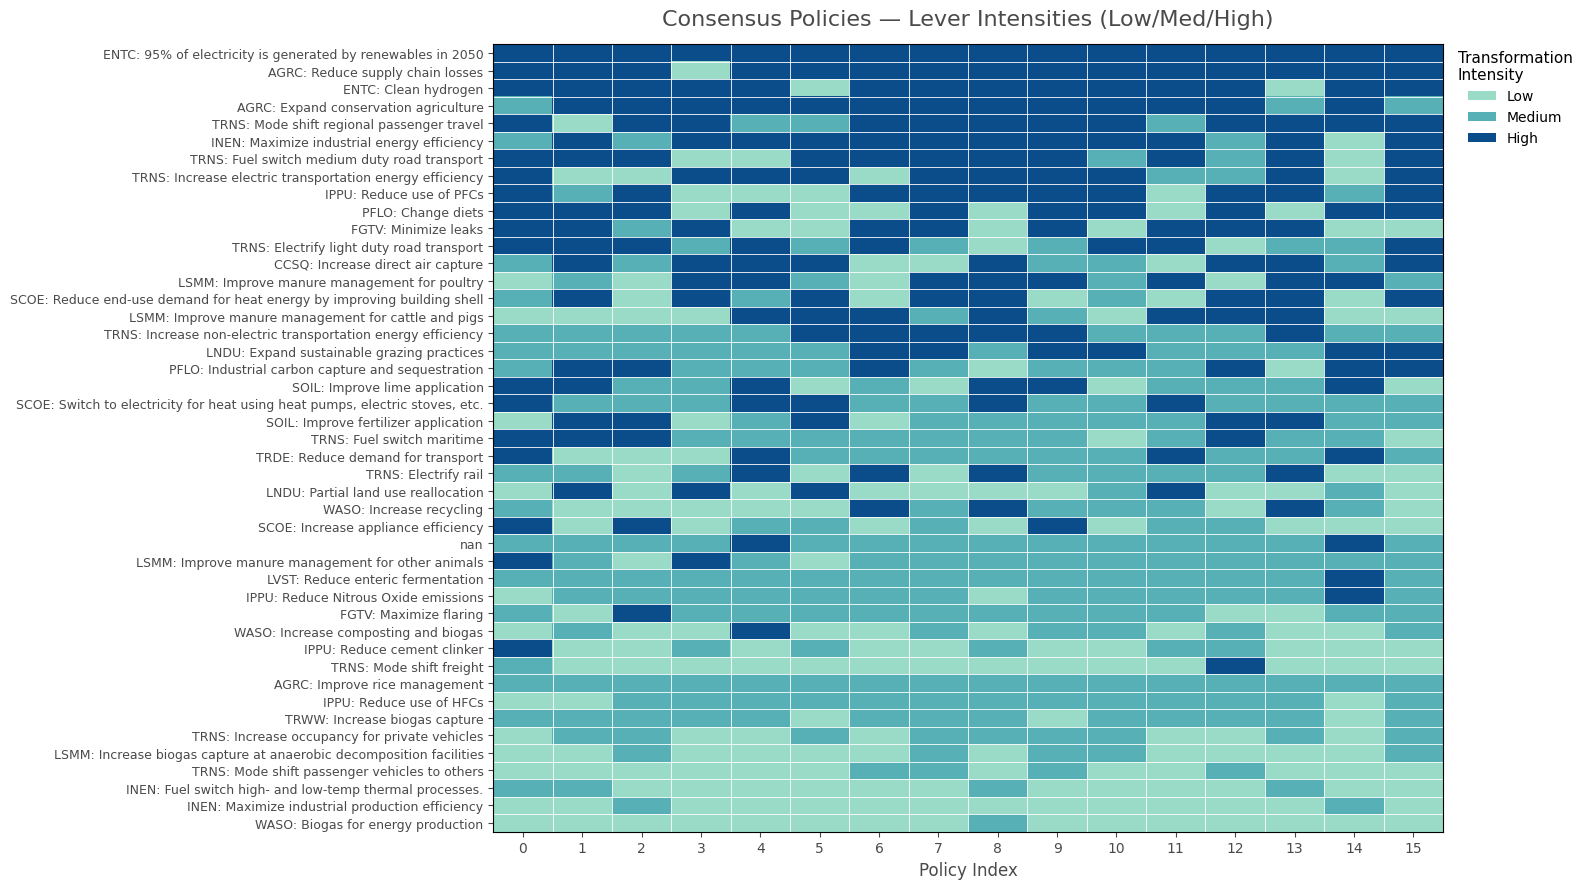

[rename] Renaming 45 lever columns with friendly names.
[heatmap] Using 45 lever cols with N < 46.
[heatmap] 'IndustryEnergyInvestment — Best Policy (from Chunk 1)': 45 levers × 1 policies.


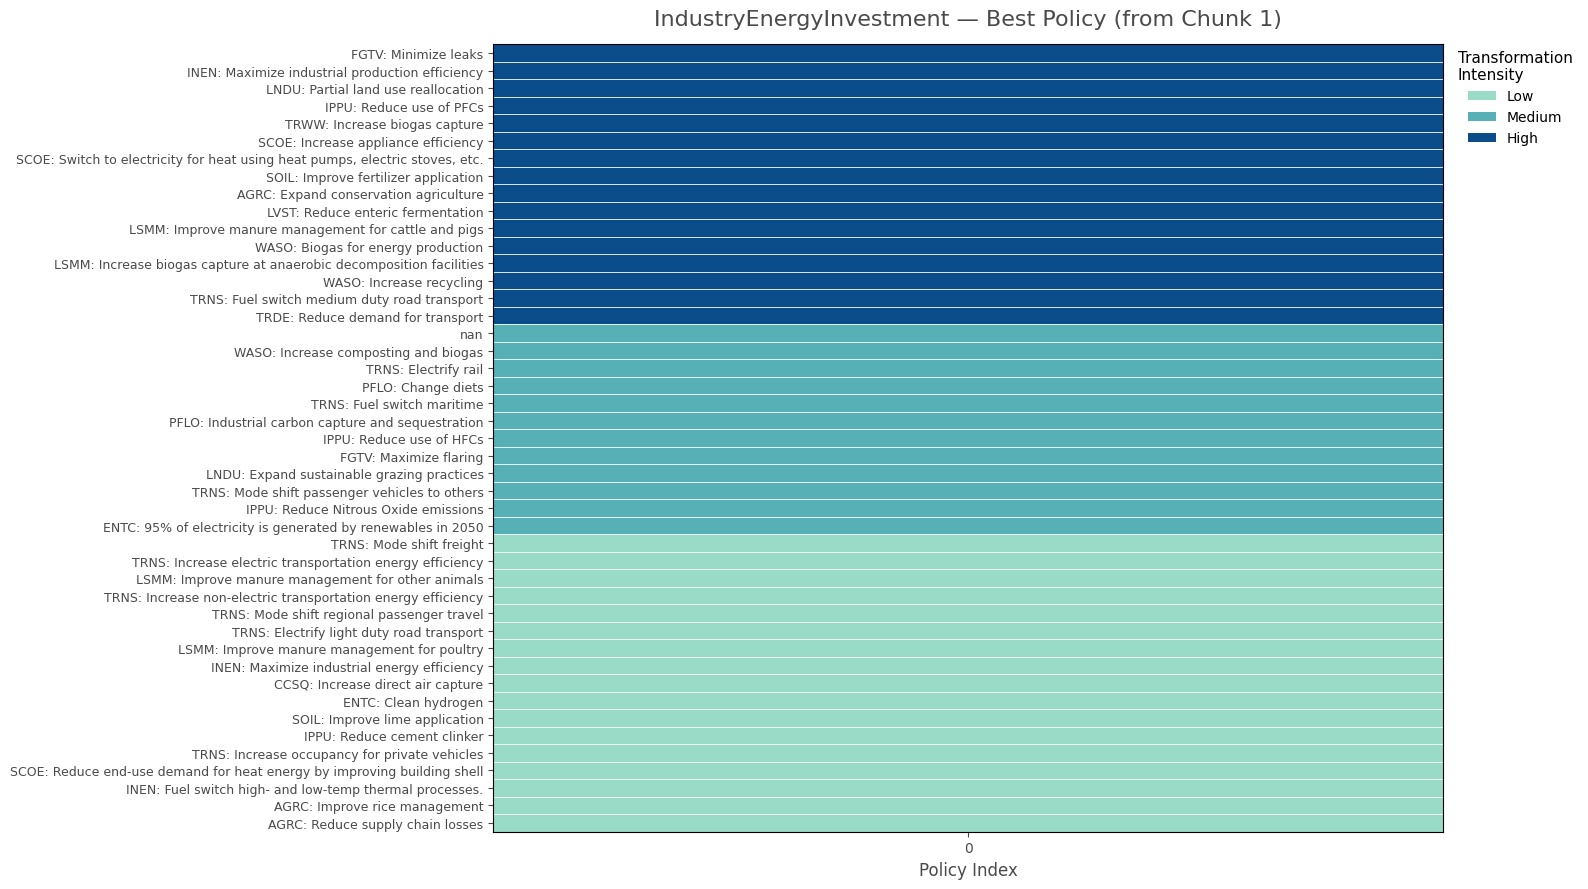

[rename] Renaming 45 lever columns with friendly names.
[heatmap] Using 45 lever cols with N < 46.
[heatmap] 'IndustryEnergyInvestment — Pareto Policies (from Chunk 1)': 45 levers × 300 policies.


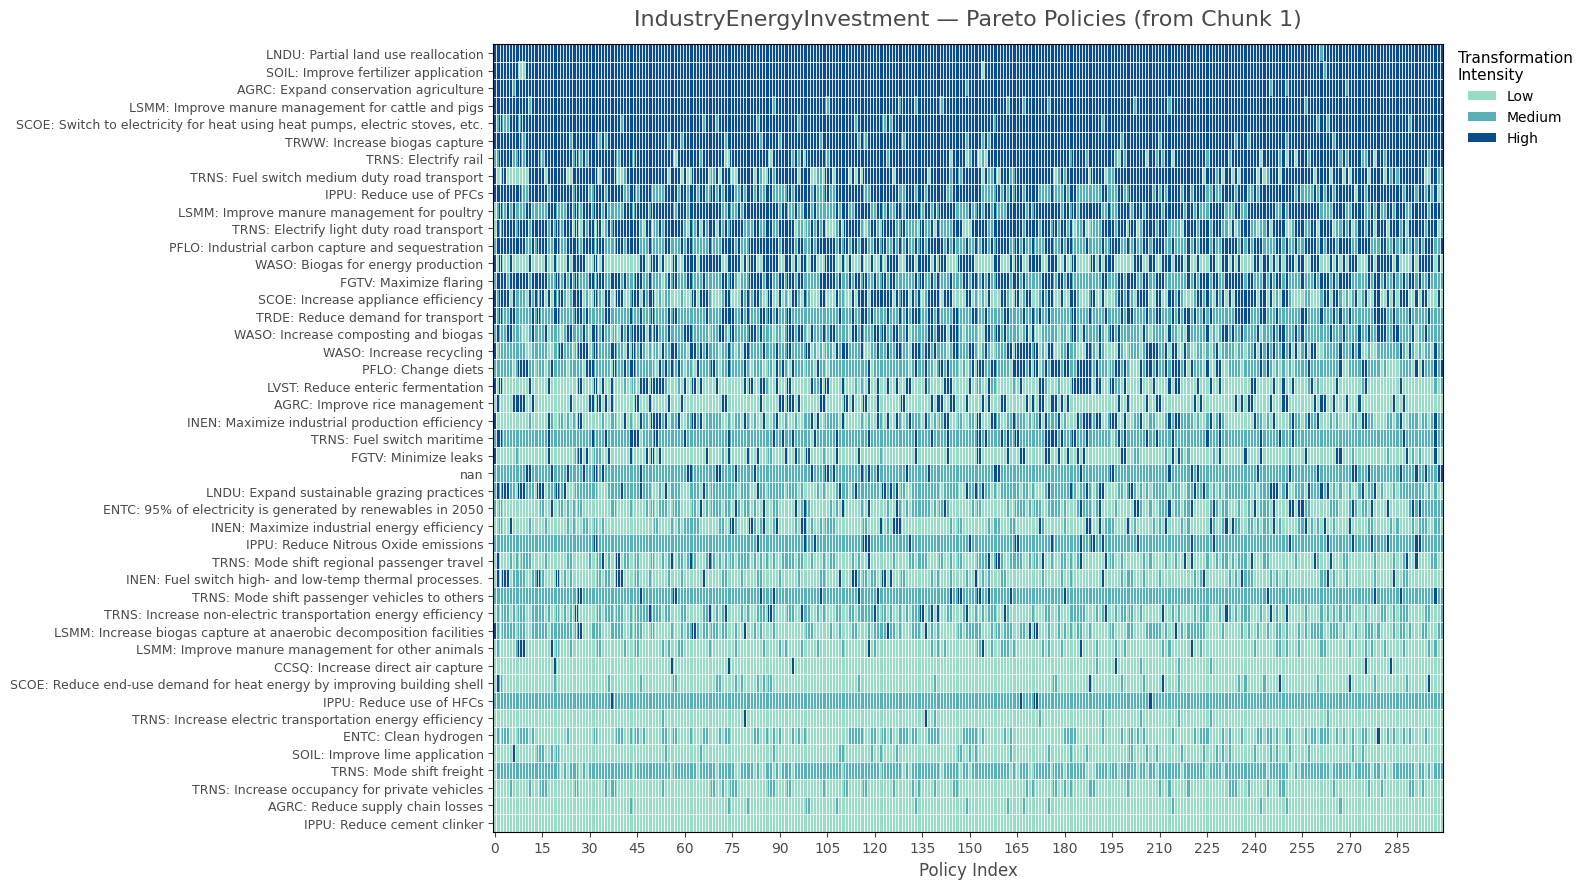

[rename] Renaming 45 lever columns with friendly names.
[heatmap] Using 45 lever cols with N < 46.
[heatmap] 'EmissionsReduction — Best Policy (from Chunk 1)': 45 levers × 1 policies.


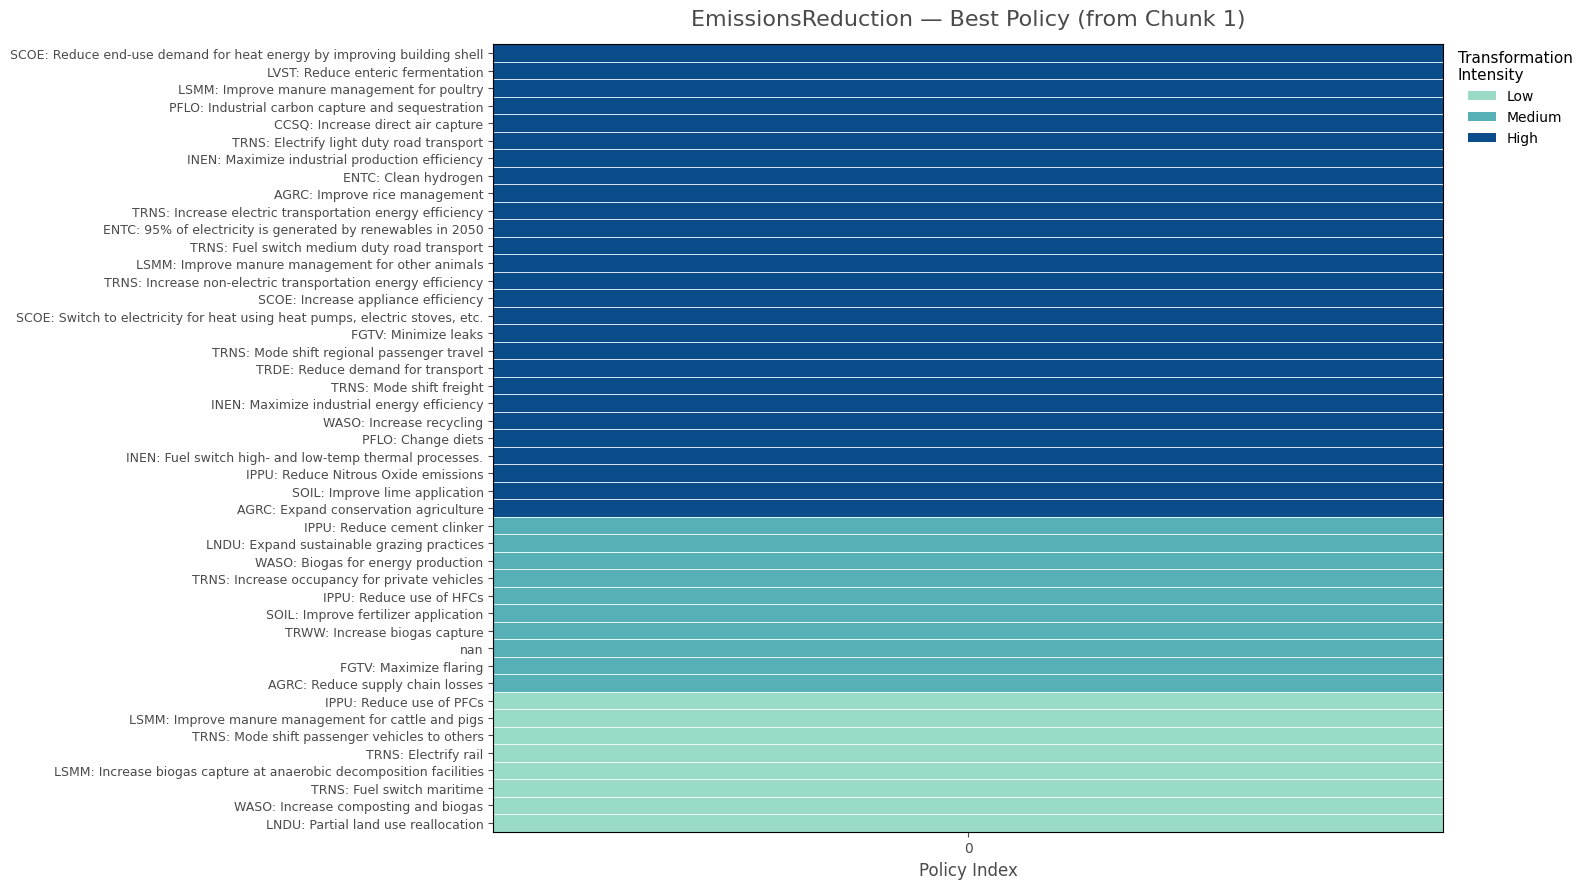

[rename] Renaming 45 lever columns with friendly names.
[heatmap] Using 45 lever cols with N < 46.
[heatmap] 'EmissionsReduction — Pareto Policies (from Chunk 1)': 45 levers × 300 policies.


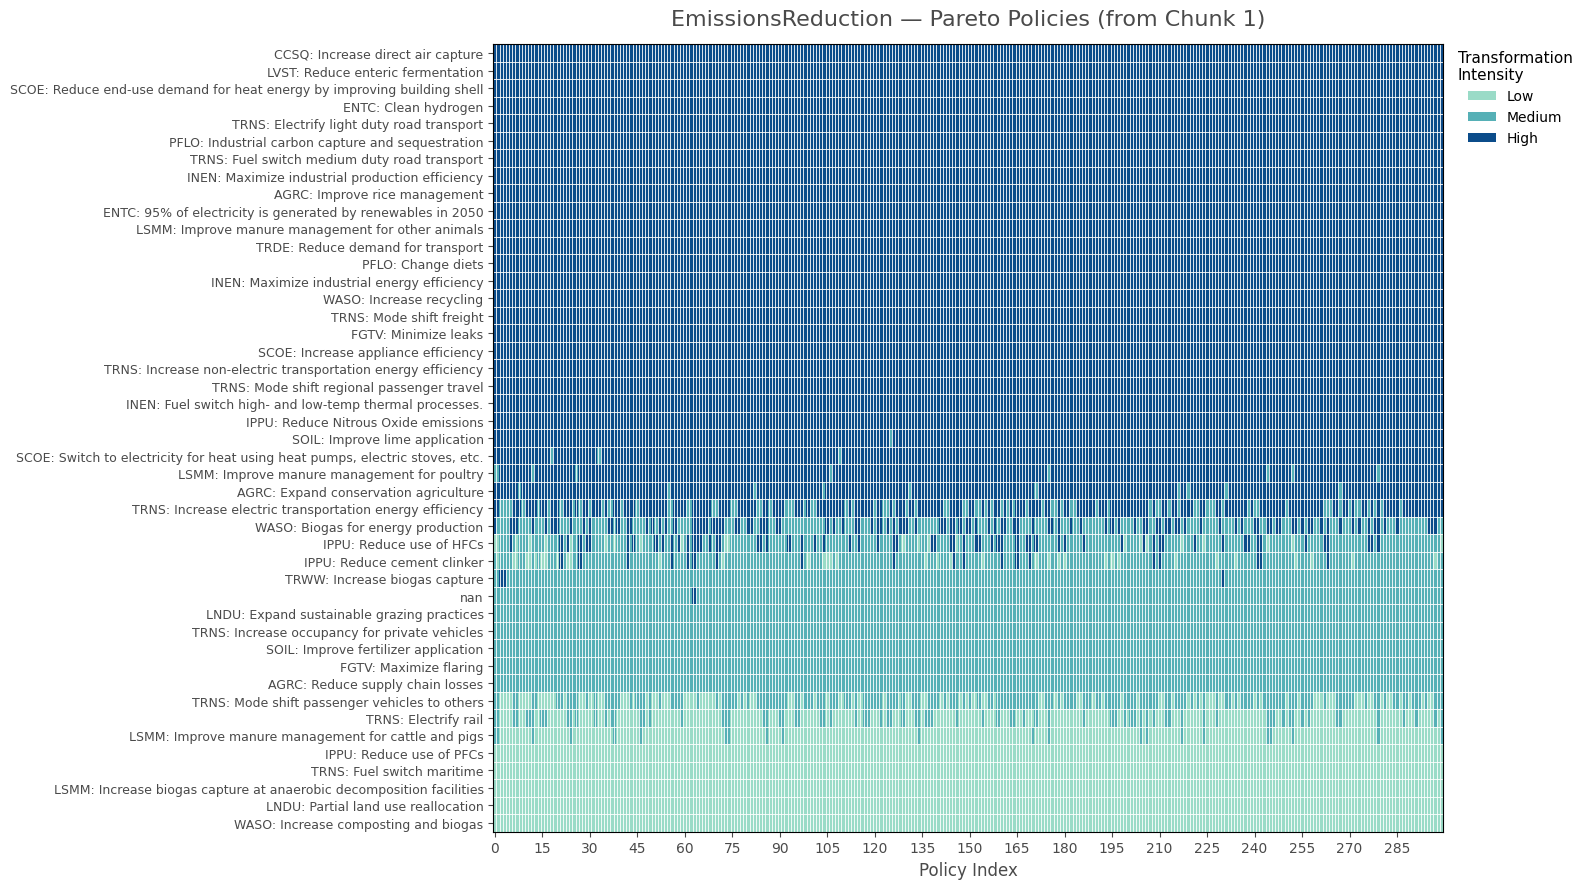

[rename] Renaming 45 lever columns with friendly names.
[heatmap] Using 45 lever cols with N < 46.
[heatmap] 'PlaceToLive — Best Policy (from Chunk 1)': 45 levers × 1 policies.


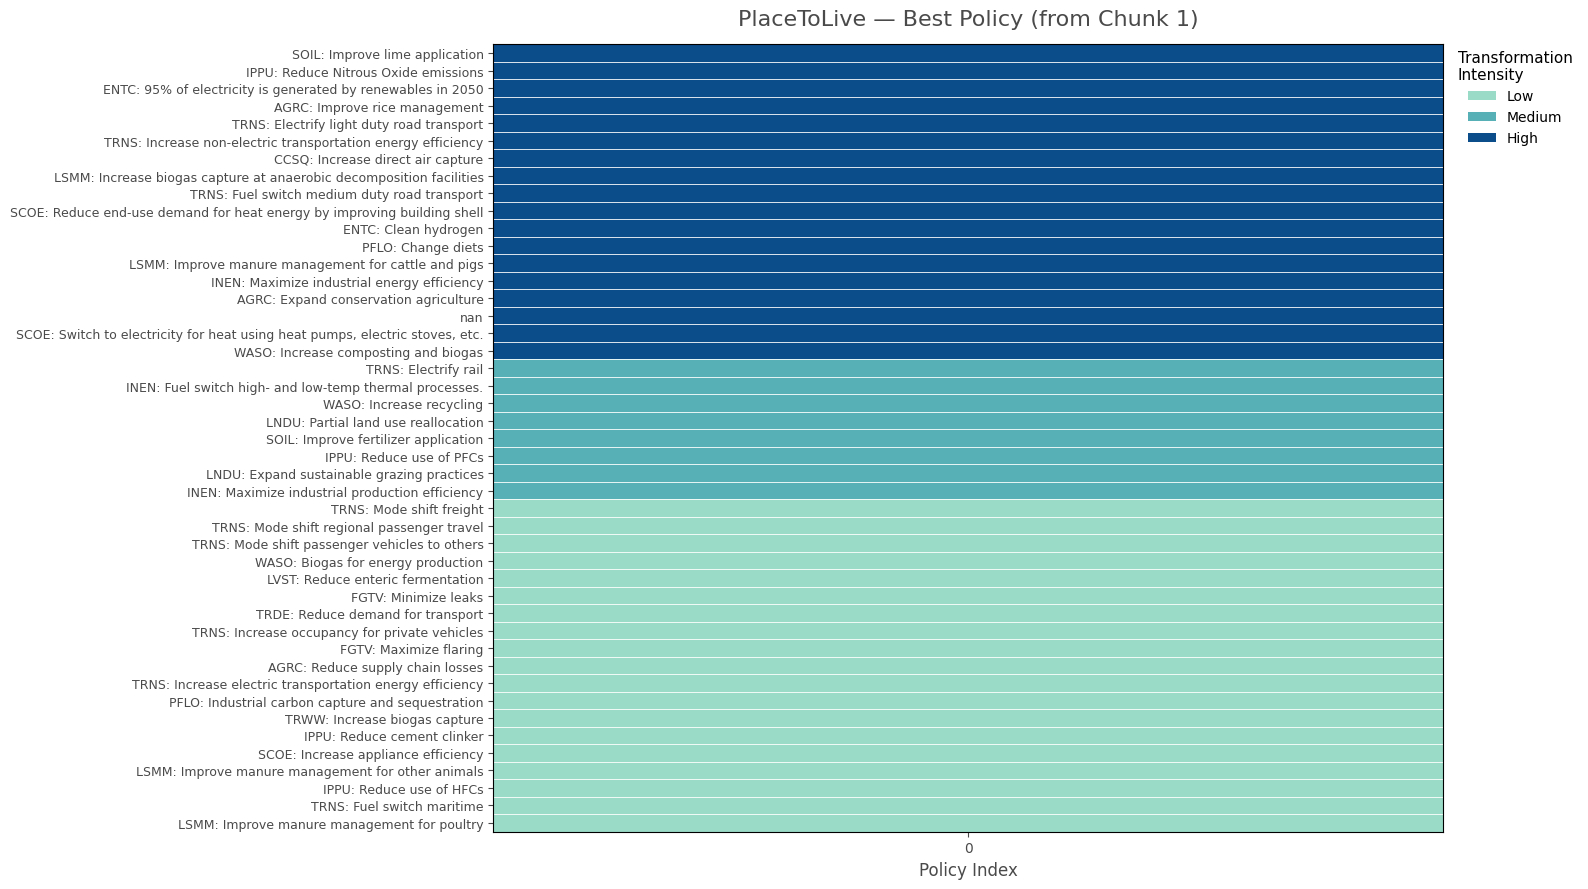

[rename] Renaming 45 lever columns with friendly names.
[heatmap] Using 45 lever cols with N < 46.
[heatmap] 'PlaceToLive — Pareto Policies (from Chunk 1)': 45 levers × 300 policies.


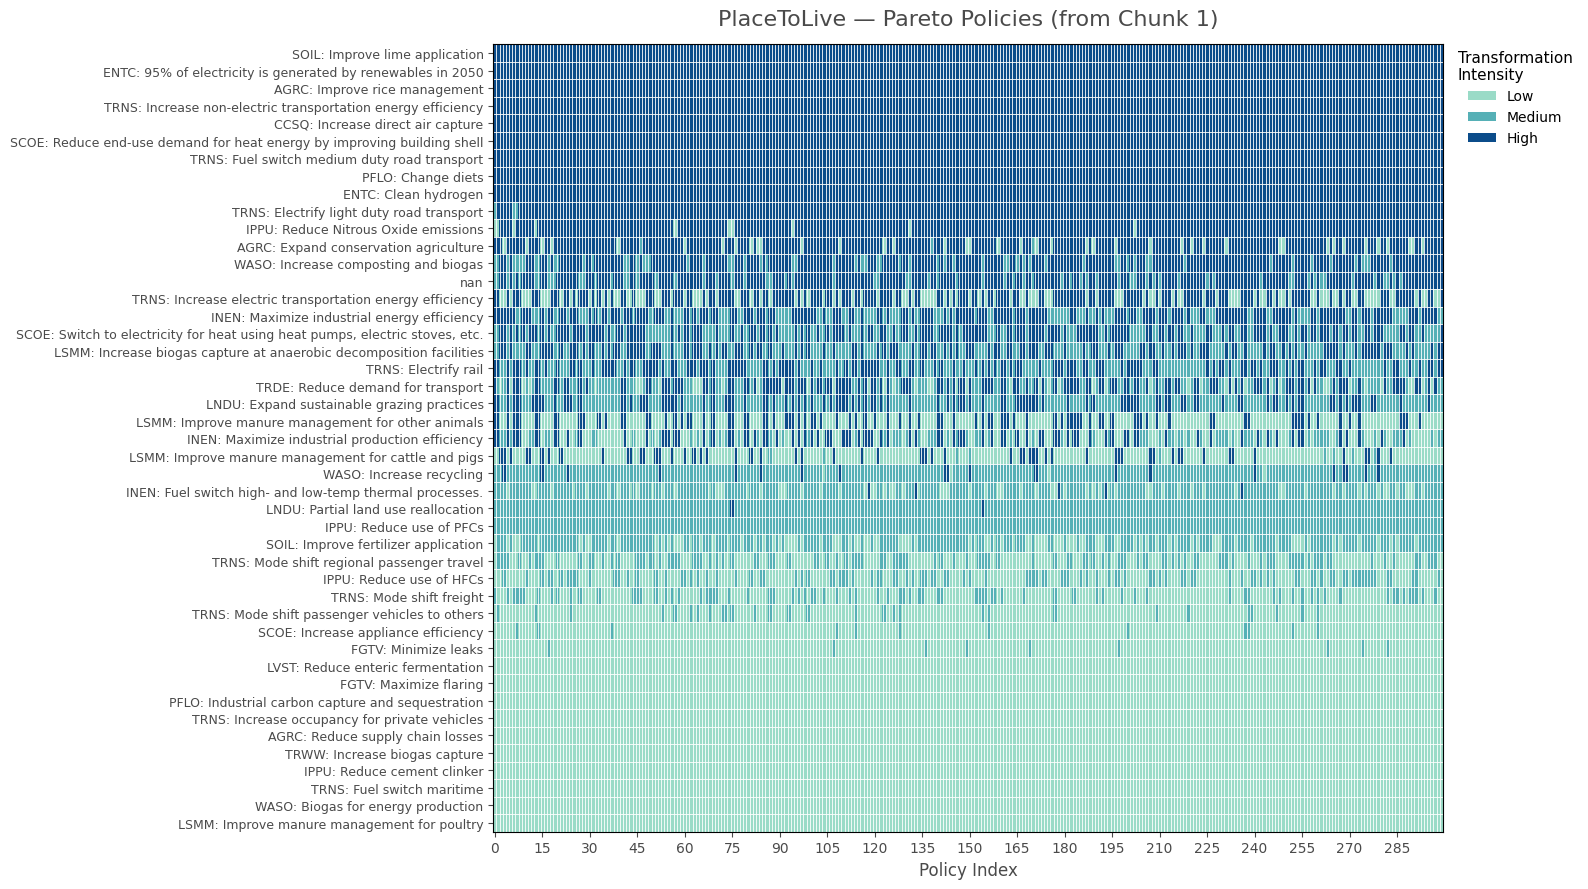

In [5]:
# ==============================================
# Heatmaps (self-contained, robust, with renaming support)
# ==============================================

import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from typing import List, Tuple, Dict, Optional

plt.rcParams["font.family"] = "DejaVu Sans"
TEXT_GRAY = "#4a4a4a"

# ---------- A) Mapping helpers (optional, used when available) ----------
def _build_map(t_src, g_src) -> Dict[int, str]:
    """Return {variable_trajectory_group -> friendly name}."""
    t = t_src if isinstance(t_src, pd.DataFrame) else pd.read_csv(str(t_src))
    if not {"transformation_code", "transformation_name"} <= set(t.columns):
        # fallback if first two columns are the mapping
        t = t.rename(columns={t.columns[0]: "transformation_code", t.columns[1]: "transformation_name"})
    g = g_src if isinstance(g_src, pd.DataFrame) else pd.read_csv(str(g_src))
    m = g.merge(t, on="transformation_code", how="left")
    m["name"] = (
        m["transformation_name"].astype(str)
        .str.replace(r"^Default Value -\s*", "", regex=True)
        .str.strip()
    )
    out = (
        m.dropna(subset=["name"])
         .drop_duplicates("variable_trajectory_group")
         .set_index("variable_trajectory_group")["name"]
         .to_dict()
    )
    return out

def _maybe_get_group_to_name() -> Optional[Dict[int, str]]:
    """Try to obtain a {group_id -> name} mapping from globals or common paths."""
    # 1) If a ready-made mapping is in globals, use it
    if "group_to_name" in globals() and isinstance(group_to_name, dict) and group_to_name:
        return group_to_name

    # 2) If CSV paths are known, build from them
    if "TRANSFORMATIONS_CSV" in globals() and "GROUPS_CSV" in globals():
        try:
            return _build_map(TRANSFORMATIONS_CSV, GROUPS_CSV)
        except Exception as e:
            print(f"[rename] Could not build mapping from provided CSVs: {e}")

    # 3) Try to infer from SIMULATION_DIR_PATH (if present)
    try:
        if "SIMULATION_DIR_PATH" in globals():
            t_csv = os.path.join(SIMULATION_DIR_PATH, "transformation_names_clean.csv")
            g_csv = os.path.join(SIMULATION_DIR_PATH, "VARIABLE_TRAJECTORY_GROUPS_L (1).csv")
            if os.path.exists(t_csv) and os.path.exists(g_csv):
                return _build_map(t_csv, g_csv)
    except Exception as e:
        print(f"[rename] Could not auto-build mapping from SIMULATION_DIR_PATH: {e}")

    print("[rename] No group→name mapping available. Heatmaps will use original column names.")
    return None

def _rename_group_cols(df: pd.DataFrame, gmap: Dict[int, str]) -> pd.DataFrame:
    """Append friendly names to group_<id> columns: -> group_<id>_<friendly_name>."""
    if df is None or df.empty or not gmap:
        return df
    df = df.copy()
    pat = re.compile(r"^group_(\d+)(?:_|$)")
    ren = {}
    for c in df.columns:
        m = pat.match(str(c))
        if m:
            n = int(m.group(1))
            nm = gmap.get(n)
            if nm:
                ren[c] = f"group_{n}_{nm}"
    if ren:
        print(f"[rename] Renaming {len(ren)} lever columns with friendly names.")
    return df.rename(columns=ren)

# ---------- B) Heatmap helpers ----------
def _find_lever_cols(df: pd.DataFrame, prefer_max_idx_exclusive: int = 46) -> List[str]:
    """Prefer group_<N> with N<46; if none, fall back to any 'group_' columns."""
    cols = list(df.columns)
    rx_num = re.compile(r"^group_(\d+)(?:_|$)")
    with_num = []
    plain_group = []
    for c in cols:
        m = rx_num.match(str(c))
        if m:
            n = int(m.group(1))
            if n < prefer_max_idx_exclusive:
                with_num.append(c)
        elif str(c).startswith("group_"):
            plain_group.append(c)

    if with_num:
        with_num.sort(key=lambda x: (int(rx_num.match(x).group(1)), x))
        print(f"[heatmap] Using {len(with_num)} lever cols with N < {prefer_max_idx_exclusive}.")
        return with_num

    if plain_group:
        plain_group.sort()
        print(f"[heatmap] No group_<N< {prefer_max_idx_exclusive}> found; "
              f"falling back to {len(plain_group)} 'group_' columns.")
        return plain_group

    # ultimate fallback: any column that starts with group_
    alt = [c for c in cols if str(c).startswith("group_")]
    if alt:
        alt.sort()
        print(f"[heatmap] Fallback: found {len(alt)} columns starting with 'group_'.")
        return alt

    print("[heatmap] No lever-like columns found (prefix 'group_').")
    return []

def _coerce_numeric_levers(df: pd.DataFrame, lever_cols: List[str]) -> pd.DataFrame:
    """Coerce only lever cols to numeric; fill NaNs with 0.0; keep other cols unchanged."""
    df = df.copy()
    for c in lever_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    if lever_cols:
        before = df[lever_cols].isna().sum().sum()
        df[lever_cols] = df[lever_cols].fillna(0.0).astype("float32")
        after = df[lever_cols].isna().sum().sum()
        if before:
            print(f"[heatmap] Coerced {len(lever_cols)} levers; NaNs before={before}, after={after}.")
    return df

def _bin_low_med_high(values: np.ndarray, low_thr: float = 0.25, high_thr: float = 0.75) -> np.ndarray:
    vals = np.clip(values, 0.0, 1.0)
    bins = np.zeros_like(vals, dtype=int)             # Low
    bins[(vals >= low_thr) & (vals < high_thr)] = 1   # Med
    bins[vals >= high_thr] = 2                        # High
    return bins

def _order_rows_by_intensity(Z: np.ndarray, M: pd.DataFrame) -> np.ndarray:
    high_cnt = (Z == 2).sum(axis=1)
    med_cnt  = (Z == 1).sum(axis=1)
    mean_val = M.to_numpy(dtype=float).mean(axis=1)
    # primary key last in lexsort → use negatives for descending
    return np.lexsort((-mean_val, -med_cnt, -high_cnt))

def plot_transformation_heatmap(
    policies_df: pd.DataFrame,
    title: str = "Transformations in Policies",
    low_thr: float = 0.25,
    high_thr: float = 0.75,
    figsize: Tuple[int, int] = (16, 9),
    prefer_max_idx_exclusive: int = 46,
):
    if not isinstance(policies_df, pd.DataFrame) or policies_df.empty:
        print(f"[heatmap] No data to plot for: {title}")
        return

    # 1) Detect lever columns
    lever_cols = _find_lever_cols(policies_df, prefer_max_idx_exclusive=prefer_max_idx_exclusive)
    if not lever_cols:
        print(f"[heatmap] Skipping '{title}': no lever columns found.")
        return

    # 2) Coerce numeric on lever columns only
    policies_df = _coerce_numeric_levers(policies_df, lever_cols)

    # 3) Build matrix (rows = levers, cols = policies)
    M = policies_df[lever_cols].T  # (n_levers, n_policies)
    print(f"[heatmap] '{title}': {M.shape[0]} levers × {M.shape[1]} policies.")

    # 4) Bin and order
    Z = _bin_low_med_high(M.to_numpy(dtype=float), low_thr=low_thr, high_thr=high_thr)
    order = _order_rows_by_intensity(Z, M)
    M = M.iloc[order, :]
    Z = Z[order, :]
    lever_cols_ordered = [lever_cols[i] for i in order]

    # 5) Row labels (drop leading 'group_<digits>_')
    row_labels = [re.sub(r"^group_\d+_?", "", name) for name in lever_cols_ordered]

    # 6) Colormap and plot
    cmap = ListedColormap(["#9ADBC7", "#56B0B6", "#0B4C8A"])  # Low, Med, High
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

    fig, ax = plt.subplots(figsize=figsize)
    fig.subplots_adjust(right=0.82)
    ax.imshow(Z, aspect="auto", interpolation="nearest", cmap=cmap, norm=norm)

    ax.set_title(title, fontsize=16, pad=14, color=TEXT_GRAY)
    ax.set_xlabel("Policy Index", fontsize=12, color=TEXT_GRAY)
    ax.set_ylabel("", fontsize=12, color=TEXT_GRAY)

    n_pols = Z.shape[1]
    step = max(1, n_pols // 20)
    ax.set_xticks(np.arange(0, n_pols, step))
    ax.set_xticklabels(np.arange(n_pols)[::step], rotation=0, color=TEXT_GRAY)

    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=9, color=TEXT_GRAY)

    ax.tick_params(axis="x", colors=TEXT_GRAY)
    ax.tick_params(axis="y", colors=TEXT_GRAY)
    ax.set_xticks(np.arange(-0.5, n_pols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    legend_elems = [
        Patch(facecolor=cmap(0), edgecolor="none", label="Low"),
        Patch(facecolor=cmap(1), edgecolor="none", label="Medium"),
        Patch(facecolor=cmap(2), edgecolor="none", label="High"),
    ]
    ax.legend(
        handles=legend_elems,
        title="Transformation\nIntensity",
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0.0,
        frameon=False,
        title_fontsize=11,
    )

    plt.tight_layout()
    plt.show()

def _plot_heatmap_for(df_policies: pd.DataFrame, title: str,
                      low_thr: float = 0.25, high_thr: float = 0.75,
                      prefer_max_idx_exclusive: int = 46,
                      rename_if_possible: bool = True):
    if not isinstance(df_policies, pd.DataFrame) or df_policies.empty:
        print(f"[heatmap] No policies for: {title}")
        return
    df = df_policies
    if rename_if_possible:
        gmap = _maybe_get_group_to_name()
        if gmap:
            df = _rename_group_cols(df, gmap)
    plot_transformation_heatmap(
        df,
        title=title,
        low_thr=low_thr,
        high_thr=high_thr,
        figsize=(16, 9),
        prefer_max_idx_exclusive=prefer_max_idx_exclusive,
    )

# ---------- C) Pick data sources (consensus + narrative best/pareto) ----------
# CONSENSUS (prefer renamed if present)
_consensus_df = None
if "agree_X_renamed" in globals() and isinstance(agree_X_renamed, pd.DataFrame) and not agree_X_renamed.empty:
    _consensus_df = agree_X_renamed
elif "agree_X" in globals() and isinstance(agree_X, pd.DataFrame) and not agree_X.empty:
    _consensus_df = agree_X

def _pick_best_df(name: str) -> Optional[pd.DataFrame]:
    # prefer renamed dict if user created one earlier
    if "renamed_best_policies_by_narrative" in globals():
        df = renamed_best_policies_by_narrative.get(name)
        if isinstance(df, pd.DataFrame) and not df.empty:
            return df
    if "best_policies_by_narrative" in globals():
        df = best_policies_by_narrative.get(name)
        if isinstance(df, pd.DataFrame) and not df.empty:
            return df
    return None

def _pick_pareto_df(name: str) -> Optional[pd.DataFrame]:
    if "renamed_pareto_policies" in globals():
        df = renamed_pareto_policies.get(name)
        if isinstance(df, pd.DataFrame) and not df.empty:
            return df
    if "pareto_policies" in globals():
        df = pareto_policies.get(name)
        if isinstance(df, pd.DataFrame) and not df.empty:
            return df
    return None

# Narrative names
if "narratives_cfg" in globals() and isinstance(narratives_cfg, dict) and narratives_cfg:
    _narr_names = list(narratives_cfg.keys())
else:
    _narr_names = ["IndustryEnergyInvestment", "EmissionsReduction", "PlaceToLive"]

# ================= RUN: 4 Heatmaps =================

# 1) CONSENSUS policies
if _consensus_df is not None:
    _plot_heatmap_for(
        _consensus_df,
        title="Consensus Policies — Lever Intensities (Low/Med/High)",
        rename_if_possible=True  # re-apply mapping if needed
    )
else:
    print("[heatmap] Skipped consensus heatmap: no consensus DataFrame found.")

# 2–4) Each narrative: best + Pareto
for name in _narr_names:
    best_df = _pick_best_df(name)
    if best_df is not None:
        _plot_heatmap_for(best_df, title=f"{name} — Best Policy (from Chunk 1)", rename_if_possible=True)
    else:
        print(f"[heatmap] Skipped best policy heatmap for '{name}': not found or empty.")

    pareto_df = _pick_pareto_df(name)
    if pareto_df is not None:
        _plot_heatmap_for(pareto_df, title=f"{name} — Pareto Policies (from Chunk 1)", rename_if_possible=True)
    else:
        print(f"[heatmap] Skipped Pareto heatmap for '{name}': not found or empty.")


## Parallel axes plots

### Optimziation for each perspective

[saved PDF] E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\parallel_axes_IndustryEnergyInvestment.pdf


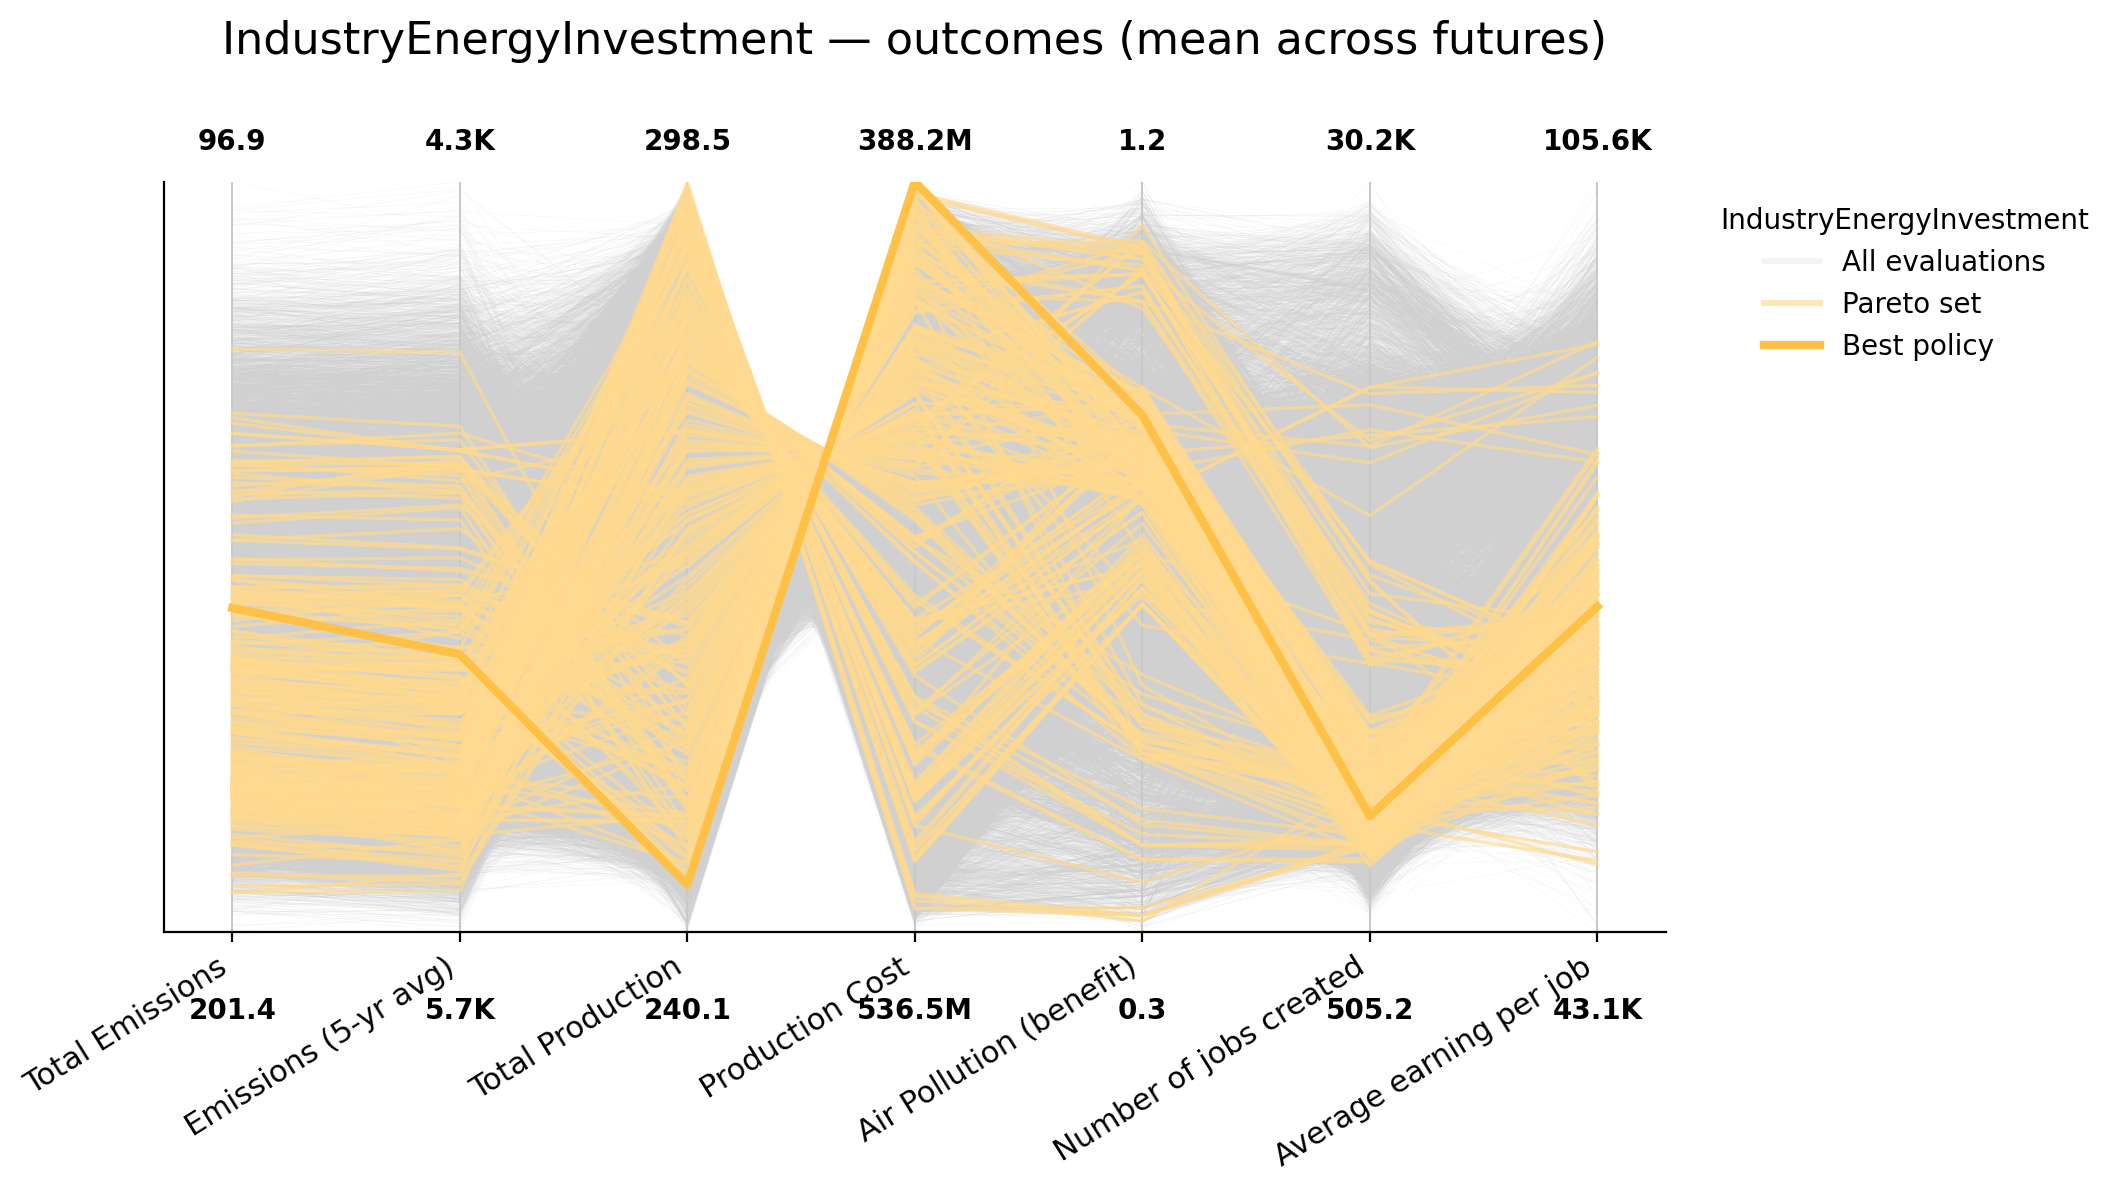

[saved PDF] E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\parallel_axes_EmissionsReduction.pdf


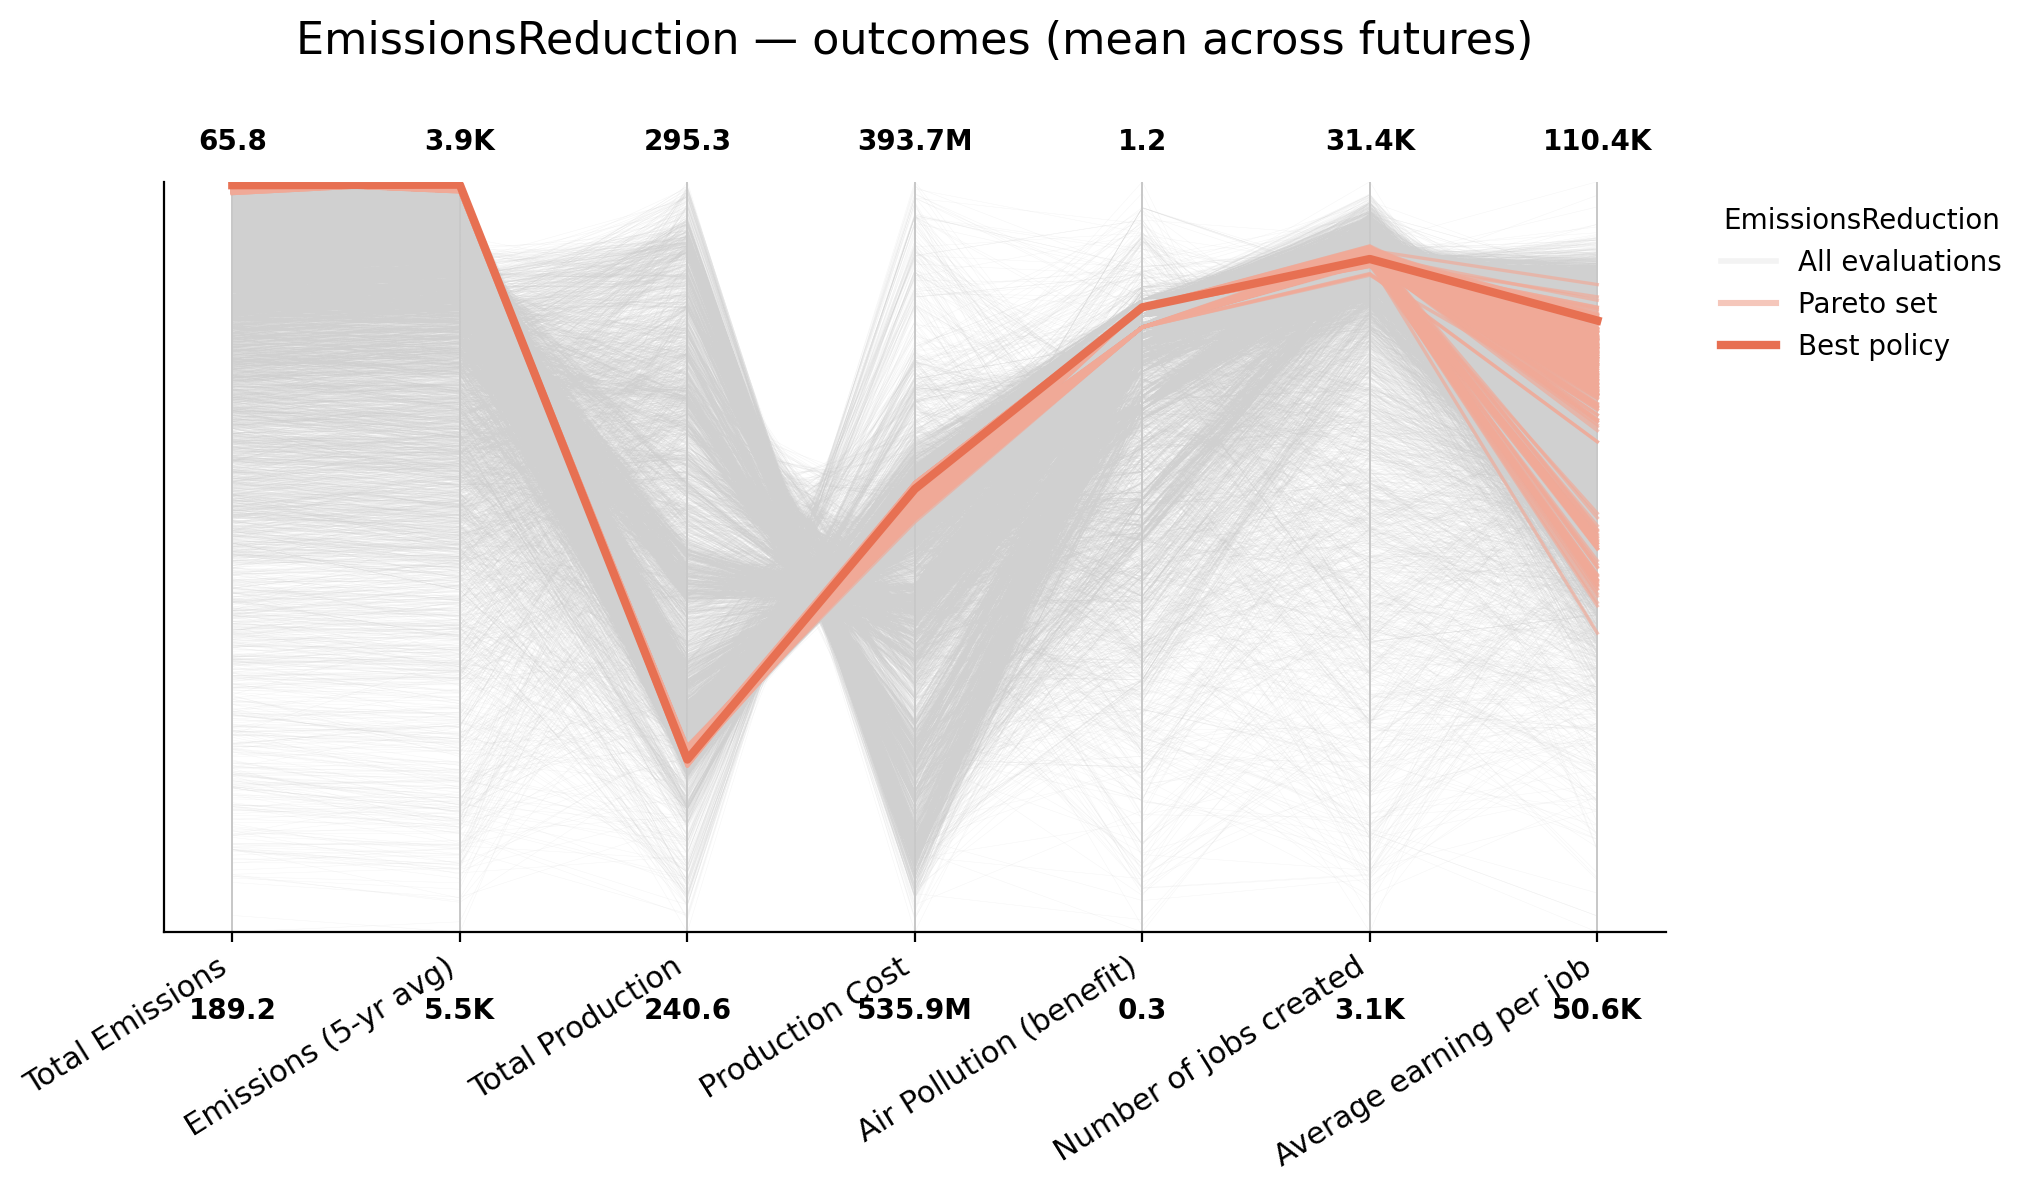

[saved PDF] E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\parallel_axes_PlaceToLive.pdf


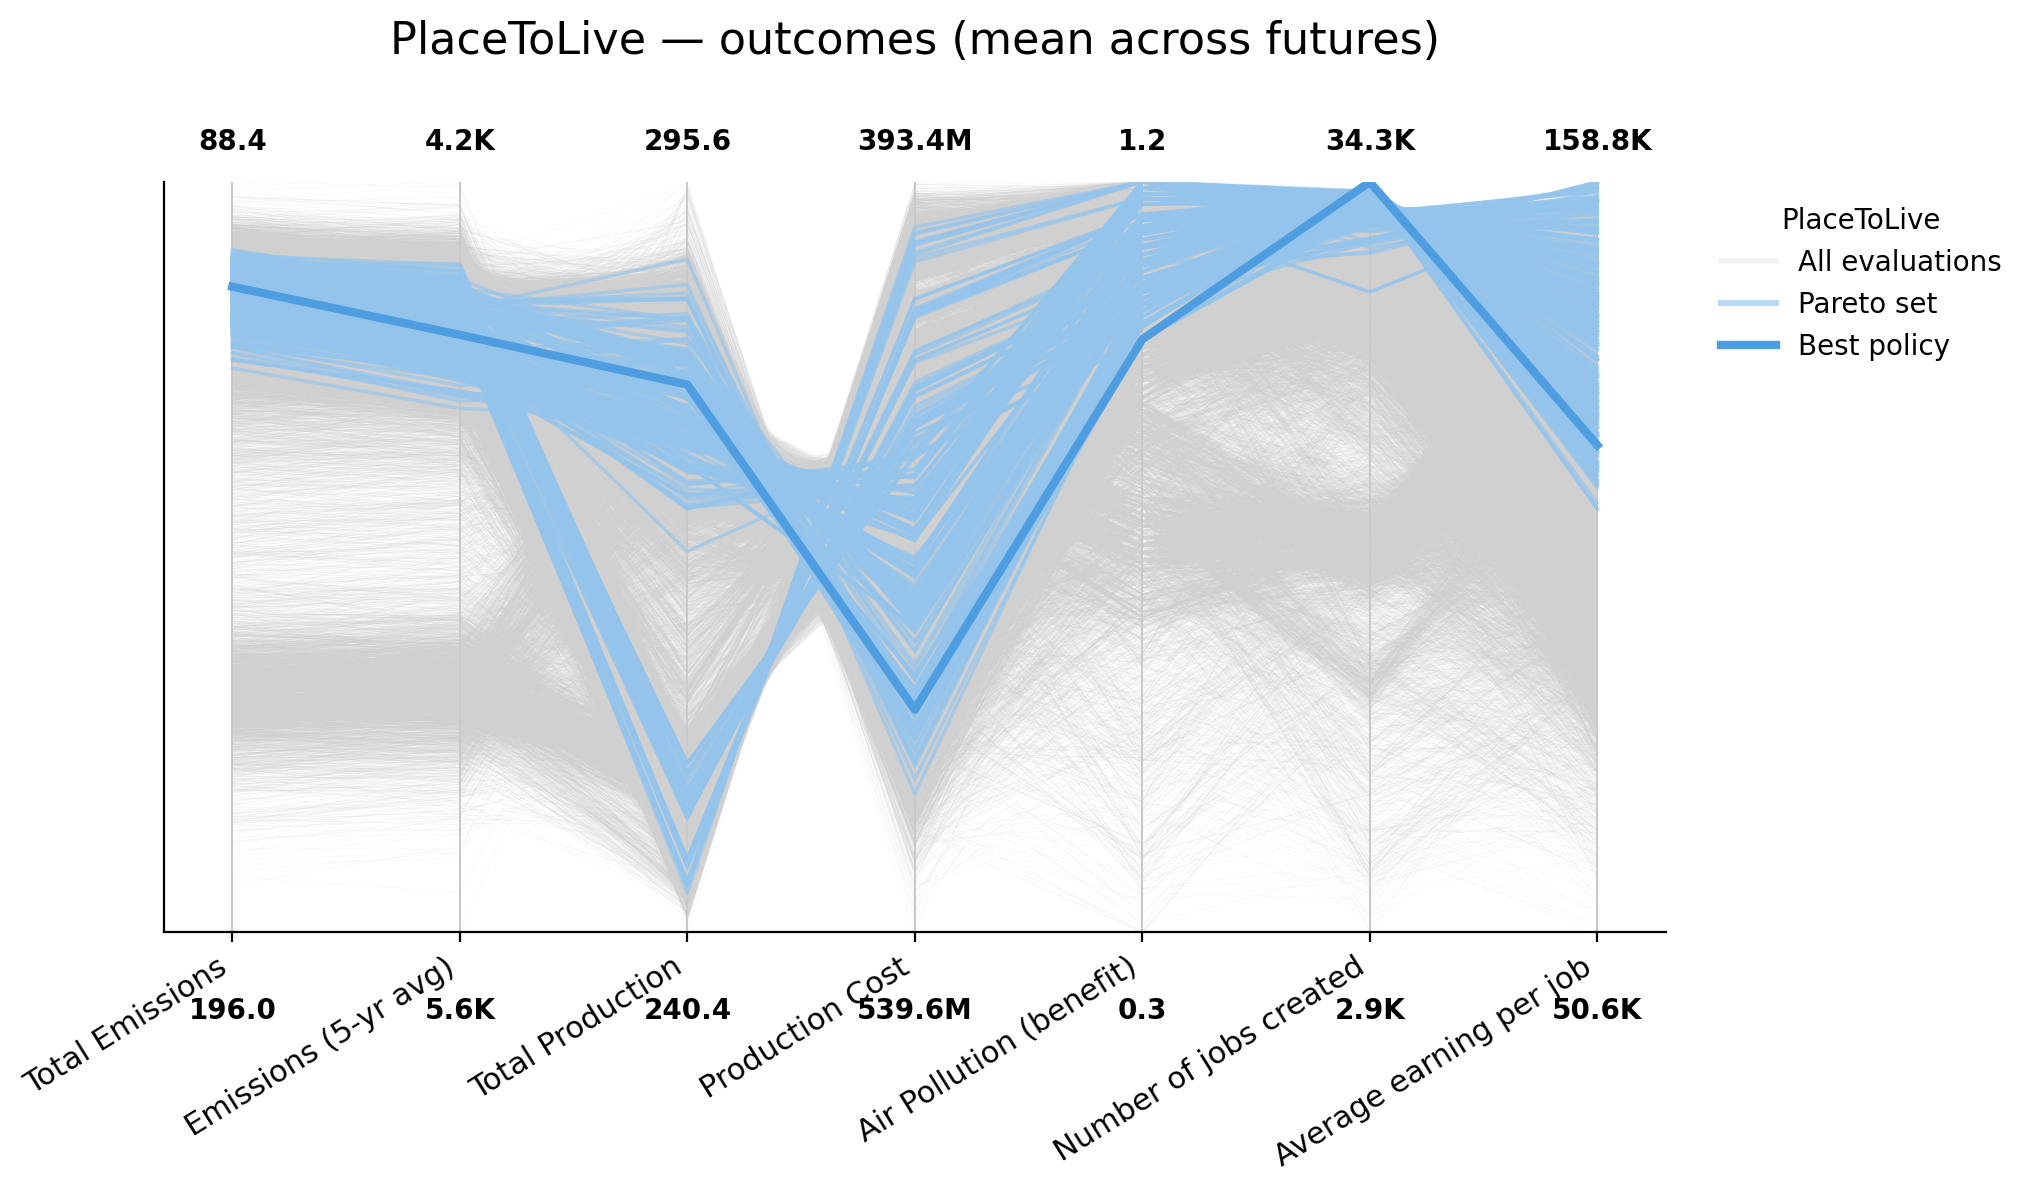

In [6]:
# ========================= Per-Narrative Plots (ALL evals + Pareto overlay, optional baselines) =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

# ---- Required globals from earlier chunks ----
_required = [
    "pipeline", "train_metrics", "SCENARIOS", "narratives_cfg",
    "best_policies_by_narrative", "evaluated_candidates_by_narrative"
]
_missing = [x for x in _required if x not in globals()]
if _missing:
    raise RuntimeError(f"Missing required globals from Chunk 1/2: {_missing}")

# Optional: Pareto decision vectors per narrative (from Chunk 1)
_has_pareto = "pareto_policies" in globals() and isinstance(pareto_policies, dict)

# ---- PDF output: absolute Windows path (auto-created) ----
PDF_ABS_DIR = Path(r"E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs")

# ---- Baselines (optional subtraction) ----
BASELINE_ON = False  # <<<<< set to True to subtract baselines; False to leave raw values unchanged
BASELINES = {
    "production_total":        1.269096e+09,
    "production_cost_total":   1.888108e+10,
}

def _collect_objectives_and_senses(narratives_cfg: dict[str, list[tuple[str, str]]]):
    senses = {}
    for _, pairs in narratives_cfg.items():
        for metric, sense in pairs:
            senses[metric] = sense.lower()
    ordered = [
        "emission_total",
        "emission_avg_last_five_years",
        "production_total",
        "production_cost_total",
        "air_pollution",
        "num_jobs",
        "earning_per_job",
    ]
    metrics = [m for m in ordered if m in senses]
    sense_by_obj = {m: senses[m] for m in metrics}
    return metrics, sense_by_obj

metrics7, sense_by_obj7 = _collect_objectives_and_senses(narratives_cfg)

# Pretty labels (no delta wording)
label_map = {
    "emission_total": "Total Emissions",
    "emission_avg_last_five_years": "Emissions (5-yr avg)",
    "production_total": "Total Production",
    "production_cost_total": "Production Cost",
    "air_pollution": "Air Pollution (benefit)",
    "num_jobs": "Number of jobs created",
    "earning_per_job": "Average earning per job",
}

colors_by_policy = {
    "IndustryEnergyInvestment": "#FFC145",  # amber
    "EmissionsReduction": "#E76F51",        # coral
    "PlaceToLive": "#4D9DE0",               # blue
}

def _predict_metrics_for_rows_across_futures(pipeline, df_rows, scenarios, metrics) -> np.ndarray:
    """(N,S,M) RAW predictions; safe on empty input."""
    if df_rows is None or len(df_rows) == 0:
        return np.zeros((0, max(1, len(scenarios)), max(1, len(metrics))), dtype=float)
    N = len(df_rows); S = len(scenarios); M = len(metrics)
    out = np.zeros((N, S, M), dtype=float)
    for s_idx, scen in enumerate(scenarios):
        Xs = df_rows.copy()
        for k, v in scen.items():
            if k in Xs.columns:
                Xs[k] = float(v)
        pred = pipeline.predict(Xs)
        Y = pd.DataFrame(pred, columns=train_metrics)[metrics].to_numpy(dtype=float)
        out[:, s_idx, :] = Y
    return out

def _summarize_across_futures(arr_nsm: np.ndarray, reduce: str = "percentile", q: float | None = None) -> np.ndarray:
    """(N,S,M) -> (N,M) via percentile/mean/median/max/min across futures."""
    if arr_nsm.size == 0:
        return np.zeros((0, 0), dtype=float)
    if reduce == "percentile":
        if q is None:
            q = globals().get("REGRET_PERCENTILE", 75.0)
        return np.percentile(arr_nsm, q, axis=1)
    if reduce == "mean":
        return arr_nsm.mean(axis=1)
    if reduce == "median":
        return np.median(arr_nsm, axis=1)
    if reduce == "max":
        return arr_nsm.max(axis=1)
    if reduce == "min":
        return arr_nsm.min(axis=1)
    raise ValueError(f"Unknown reduce='{reduce}'")

def _kmb(v: float) -> str:
    a = abs(v)
    if a >= 1_000_000_000: return f"{v/1_000_000_000:.1f}B"
    if a >= 1_000_000:     return f"{v/1_000_000:.1f}M"
    if a >= 1_000:         return f"{v/1_000:.1f}K"
    return f"{v:.1f}"

def _lighten(color, factor=0.78):
    r, g, b = to_rgb(color)
    return (1 - (1 - r) * factor, 1 - (1 - g) * factor, 1 - (1 - b) * factor)

def _maybe_apply_baselines(df_vals: pd.DataFrame) -> pd.DataFrame:
    """Optionally subtract baselines for specified metrics; return a copy."""
    if not BASELINE_ON:
        return df_vals.copy()
    df = df_vals.copy()
    for m, b in BASELINES.items():
        if m in df.columns:
            df[m] = df[m] - float(b)
    return df

def _build_metric_table_for_rows(
    df_rows: pd.DataFrame, *, pipeline, scenarios, metrics,
    reduce="percentile", q: float | None = None
) -> pd.DataFrame:
    """Returns (N,M) in RAW units aggregated across futures; baseline subtraction optional."""
    A  = _predict_metrics_for_rows_across_futures(pipeline, df_rows, scenarios, metrics)  # (N,S,M)
    R  = _summarize_across_futures(A, reduce=reduce, q=q)                                  # (N,M)
    df = pd.DataFrame(R, columns=metrics, index=df_rows.index)
    df = _maybe_apply_baselines(df)
    return df

def plot_single_narrative(
    narrative_name: str,
    *,
    best_policies_by_narrative: dict[str, pd.DataFrame],
    evaluated_candidates_by_narrative: dict[str, pd.DataFrame],   # ALL evals (history)
    pipeline,
    scenarios,
    metrics: list[str],
    sense_by_obj: dict[str, str],
    label_map: dict[str, str] | None = None,
    color: str = "#4D9DE0",
    reduce_across_futures: str = "percentile",
    percentile_across_futures: float | None = None,  # default uses REGRET_PERCENTILE or 75
    figsize=(10.5, 6.7),
    dpi=200,
    background_lw=0.15,
    background_alpha=0.25,
    pareto_lw=1.2,
    pareto_alpha=0.65,
    best_lw=3.0,
    best_alpha=0.98,
    output_dir: str | Path | None = None,            # PNG folder (optional)
    filename_prefix: str = "parallel_axes",
    max_background: int | None = None,               # downsample candidates if huge
    save_pdf: bool = True                            # Save PDFs to PDF_ABS_DIR
):
    """
    One figure per narrative:
      • Thin tinted lines = ALL evaluated candidates (search history)
      • Medium lines      = Pareto set (if available)
      • Bold line         = BEST policy selected in Chunk 1
    Notes:
      - Optional baseline subtraction controlled by BASELINE_ON.
      - Title is higher; extra bottom margin avoids overlap with labels/annotations.
      - PDFs saved to the absolute folder PDF_ABS_DIR if save_pdf=True.
    """
    assert narrative_name in best_policies_by_narrative, f"Unknown narrative: {narrative_name}"
    assert narrative_name in evaluated_candidates_by_narrative, f"No candidates for: {narrative_name}"

    q = percentile_across_futures if percentile_across_futures is not None else globals().get("REGRET_PERCENTILE", 75.0)

    # Candidate sets
    df_best_x = best_policies_by_narrative[narrative_name].iloc[[0]]
    df_all_x  = evaluated_candidates_by_narrative.get(narrative_name, pd.DataFrame(columns=df_best_x.columns))
    if max_background and len(df_all_x) > max_background:
        df_all_x = df_all_x.sample(max_background, random_state=42)

    df_pareto_x = None
    if _has_pareto:
        df_pareto_x = pareto_policies.get(narrative_name, None)

    # Metric tables (RAW aggregated across futures), maybe baselines
    df_best_m   = _build_metric_table_for_rows(df_best_x,  pipeline=pipeline, scenarios=scenarios, metrics=metrics,
                                               reduce=reduce_across_futures, q=q)
    df_all_m    = _build_metric_table_for_rows(df_all_x,   pipeline=pipeline, scenarios=scenarios, metrics=metrics,
                                               reduce=reduce_across_futures, q=q) if len(df_all_x) else df_best_m.iloc[[]]
    df_pareto_m = (_build_metric_table_for_rows(df_pareto_x, pipeline=pipeline, scenarios=scenarios, metrics=metrics,
                                                reduce=reduce_across_futures, q=q)
                   if isinstance(df_pareto_x, pd.DataFrame) and len(df_pareto_x) else df_best_m.iloc[[]])

    # Normalize jointly (all evals + Pareto + best). Flip "min" objectives so higher=better.
    df_stack = pd.concat([df_all_m, df_pareto_m, df_best_m], axis=0)
    scaler = MinMaxScaler().fit(df_stack[metrics].to_numpy(dtype=float))

    def _norm(df_in):
        if len(df_in) == 0:
            return df_in.reindex(columns=metrics)
        vals = scaler.transform(df_in[metrics].to_numpy(dtype=float))
        df = pd.DataFrame(vals, columns=metrics, index=df_in.index)
        for c in metrics:
            if sense_by_obj[c].lower().startswith("min"):
                df[c] = 1.0 - df[c]
        return df

    df_all_n    = _norm(df_all_m)
    df_pareto_n = _norm(df_pareto_m)
    df_best_n   = _norm(df_best_m)

    # --- Plot ---
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    })
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    x = np.arange(len(metrics))
    labels = [(label_map or {}).get(c, c) for c in metrics]

    # Vertical axes
    for i in range(len(metrics)):
        ax.vlines(i, 0, 1, color="#BDBDBD", linewidth=0.6, zorder=0)
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=32, ha="right")
    ax.set_yticks([])

    # Top/bottom annotations (respect baseline choice since df_stack already reflects it)
    for i, c in enumerate(metrics):
        vmin, vmax = df_stack[c].min(), df_stack[c].max()
        is_min = sense_by_obj[c].lower().startswith("min")
        top_val = vmin if is_min else vmax
        bot_val = vmax if is_min else vmin
        ax.text(i, 1.035, _kmb(top_val), ha="center", va="bottom", fontsize=10, fontweight="bold")
        ax.text(i, -0.085, _kmb(bot_val), ha="center", va="top", fontsize=10, fontweight="bold")

    base = colors_by_policy.get(narrative_name, "#666666")
    lite = "#D0D0D0"   # force light gray for ALL evaluations
    mid  = _lighten(base, factor=0.60)

    # ALL evaluations (thin)
    for idx in df_all_n.index:
        ax.plot(x, df_all_n.loc[idx, metrics], color=lite, alpha=background_alpha, lw=background_lw, zorder=1)

    # Pareto (if available)
    if len(df_pareto_n):
        for idx in df_pareto_n.index:
            ax.plot(x, df_pareto_n.loc[idx, metrics], color=mid, alpha=pareto_alpha, lw=pareto_lw, zorder=2)

    # Best policy (bold)
    ax.plot(x, df_best_n.iloc[0][metrics], color=base, alpha=best_alpha, lw=best_lw, zorder=3)

    # Legend
    legend_lines = [Line2D([0],[0], color=lite, lw=2, alpha=background_alpha, label="All evaluations")]
    legend_labels = ["All evaluations"]
    if len(df_pareto_n):
        legend_lines.append(Line2D([0],[0], color=mid, lw=2.2, alpha=pareto_alpha, label="Pareto set"))
        legend_labels.append("Pareto set")
    legend_lines.append(Line2D([0],[0], color=base, lw=3, label="Best policy"))
    legend_labels.append("Best policy")
    ax.legend(legend_lines, legend_labels, loc="upper left", bbox_to_anchor=(1.02, 1.0),
              frameon=False, title=narrative_name)

    # Title higher + extra bottom whitespace
    ttl = f"{narrative_name} — outcomes ({reduce_across_futures} across futures"
    if reduce_across_futures == "percentile":
        ttl += f", q={q:.0f}"
    ttl += ")"
    ax.set_title(ttl, pad=30, y=1.06)
    fig.subplots_adjust(top=0.80, bottom=0.24, right=0.84)

    # Save PNG (optional) and PDF (absolute)
    fname_core = f"{filename_prefix}_{narrative_name.replace(' ', '_')}"
    if output_dir:
        output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
        png_path = output_dir / f"{fname_core}.png"
        plt.savefig(png_path, bbox_inches="tight", dpi=dpi)
        print(f"[saved PNG] {png_path}")

    if save_pdf:
        PDF_ABS_DIR.mkdir(parents=True, exist_ok=True)
        pdf_path = PDF_ABS_DIR / f"{fname_core}.pdf"
        plt.savefig(pdf_path, bbox_inches="tight", format="pdf")
        print(f"[saved PDF] {pdf_path}")

    plt.show()
    plt.close(fig)

# ============ RUN: make one figure per narrative ============
# PNGs -> set out_dir if wanted; PDFs always go to PDF_ABS_DIR when save_pdf=True
out_dir = None  # e.g., "figs_parallel_axes"

for _name in ["IndustryEnergyInvestment", "EmissionsReduction", "PlaceToLive"]:
    plot_single_narrative(
        _name,
        best_policies_by_narrative=best_policies_by_narrative,
        evaluated_candidates_by_narrative=evaluated_candidates_by_narrative,  # ALL evals (Chunk 1)
        pipeline=pipeline,
        scenarios=SCENARIOS,
        metrics=metrics7,
        sense_by_obj=sense_by_obj7,
        reduce_across_futures= "mean",
        label_map=label_map,
        color=colors_by_policy[_name],
        output_dir=out_dir,   # set a folder (e.g., "figs") to also get PNGs
        save_pdf=True         # PDFs saved to PDF_ABS_DIR
        # percentile_across_futures=90,
        # max_background=20000,
    )
# ====================================================================================================

### all three +consensus 

[consensus overlay] Using ALL-evals from 'evaluated_candidates_allobj' (51200)
[consensus overlay] No Pareto set for ALL-objectives run.
[saved PDF] E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\parallel_axes_ALLOBJECTIVES_overlay.pdf


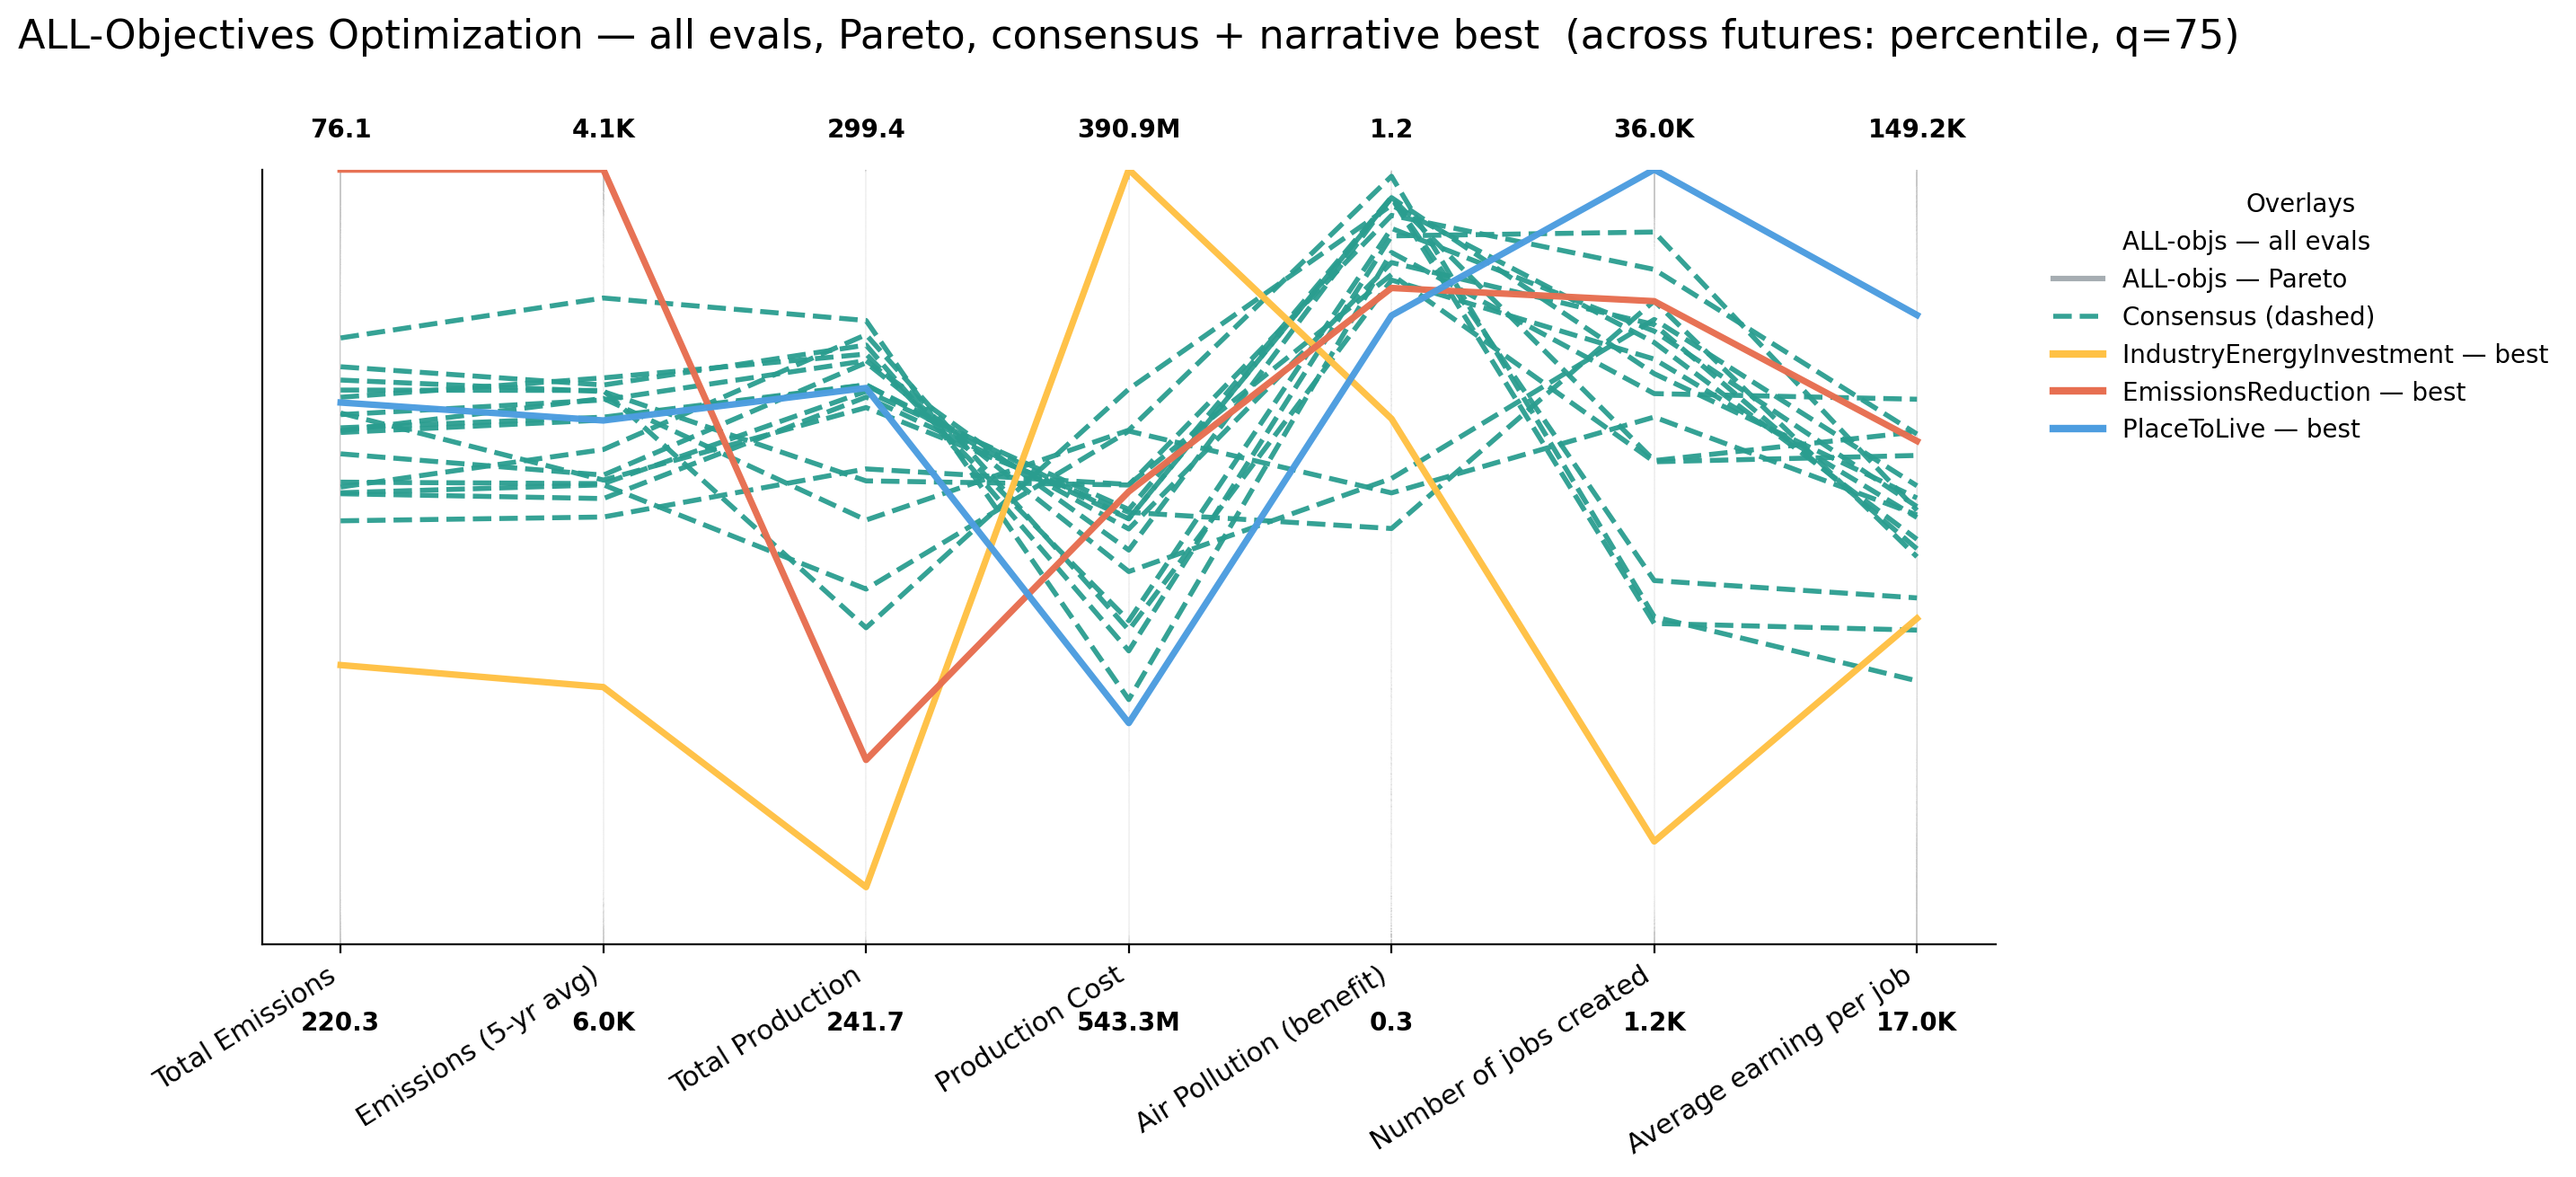

In [7]:
# ================= One Plot: ALL-Objectives Optimization Overlay (+Consensus + Narrative best) =================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

# --------- Required globals already defined in prior chunks ----------
req = ["pipeline","train_metrics","SCENARIOS","narratives_cfg",
       "best_policies_by_narrative","metrics7","sense_by_obj7","label_map","colors_by_policy"]
missing = [x for x in req if x not in globals()]
if missing:
    raise RuntimeError(f"[consensus overlay] Missing globals: {missing}")

# --------- OPTIONAL globals (auto-detected names for ALL-objectives results) ----------
# Provide your ALL-objectives optimization outputs under one of these names:
#   - ALL evaluations (history): any of  allobj_all_evals / evaluated_candidates_allobj / global_all_evals
#   - Pareto set: any of           allobj_pareto_X / pareto_X_allobj / global_pareto_X
allobj_all_evals = None
for cand_name in ["allobj_all_evals", "evaluated_candidates_allobj", "global_all_evals"]:
    if cand_name in globals() and isinstance(globals()[cand_name], pd.DataFrame):
        allobj_all_evals = globals()[cand_name]
        print(f"[consensus overlay] Using ALL-evals from '{cand_name}' ({len(allobj_all_evals)})")
        break

allobj_pareto_X = None
for cand_name in ["allobj_pareto_X", "pareto_X_allobj", "global_pareto_X", "pareto_X"]:
    if cand_name in globals() and isinstance(globals()[cand_name], pd.DataFrame):
        allobj_pareto_X = globals()[cand_name]
        print(f"[consensus overlay] Using Pareto set from '{cand_name}' ({len(allobj_pareto_X)})")
        break

# Consensus decision vectors (prefer renamed)
CONSENSUS_COLOR = "#2A9D8F"
_consensus_df = None
if "agree_X_renamed" in globals() and isinstance(agree_X_renamed, pd.DataFrame) and not agree_X_renamed.empty:
    _consensus_df = agree_X_renamed
elif "agree_X" in globals() and isinstance(agree_X, pd.DataFrame) and not agree_X.empty:
    _consensus_df = agree_X

# --------- PDF output path ----------
PDF_ABS_DIR = Path(r"E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs")
PDF_ABS_DIR.mkdir(parents=True, exist_ok=True)

# --------- Baseline toggle (reused from previous chunks) ----------
if "BASELINE_ON" not in globals():  BASELINE_ON = False
if "BASELINES" not in globals():
    BASELINES = {
        "production_total":        1.269096e+09,
        "production_cost_total":   1.888108e+10,
    }

def _predict_metrics_for_rows_across_futures(pipeline, df_rows, scenarios, metrics) -> np.ndarray:
    """(N,S,M) RAW predictions; safe on empty input."""
    if df_rows is None or len(df_rows) == 0:
        return np.zeros((0, max(1, len(scenarios)), max(1, len(metrics))), dtype=float)
    N = len(df_rows); S = len(scenarios); M = len(metrics)
    out = np.zeros((N, S, M), dtype=float)
    for s_idx, scen in enumerate(scenarios):
        Xs = df_rows.copy()
        for k, v in scen.items():
            if k in Xs.columns:
                Xs[k] = float(v)
        pred = pipeline.predict(Xs)
        Y = pd.DataFrame(pred, columns=train_metrics)[metrics].to_numpy(dtype=float)
        out[:, s_idx, :] = Y
    return out

def _summarize_across_futures(arr_nsm: np.ndarray, reduce: str = "percentile", q: float | None = None) -> np.ndarray:
    if arr_nsm.size == 0:
        return np.zeros((0, 0), dtype=float)
    if reduce == "percentile":
        if q is None:
            q = globals().get("REGRET_PERCENTILE", 75.0)
        return np.percentile(arr_nsm, q, axis=1)
    if reduce == "mean":   return arr_nsm.mean(axis=1)
    if reduce == "median": return np.median(arr_nsm, axis=1)
    if reduce == "max":    return arr_nsm.max(axis=1)
    if reduce == "min":    return arr_nsm.min(axis=1)
    raise ValueError(f"Unknown reduce='{reduce}'")

def _maybe_apply_baselines(df_vals: pd.DataFrame) -> pd.DataFrame:
    if not BASELINE_ON:
        return df_vals.copy()
    df = df_vals.copy()
    for m, b in BASELINES.items():
        if m in df.columns:
            df[m] = df[m] - float(b)
    return df

def _build_metric_table_for_rows(
    df_rows: pd.DataFrame, *, pipeline, scenarios, metrics,
    reduce="percentile", q: float | None = None
) -> pd.DataFrame:
    A  = _predict_metrics_for_rows_across_futures(pipeline, df_rows, scenarios, metrics)
    R  = _summarize_across_futures(A, reduce=reduce, q=q)
    df = pd.DataFrame(R, columns=metrics, index=df_rows.index)
    df = _maybe_apply_baselines(df)
    return df

def _kmb(v: float) -> str:
    a = abs(v)
    if a >= 1_000_000_000: return f"{v/1_000_000_000:.1f}B"
    if a >= 1_000_000:     return f"{v/1_000_000:.1f}M"
    if a >= 1_000:         return f"{v/1_000:.1f}K"
    return f"{v:.1f}"

def _lighten(color, factor=0.78):
    from matplotlib.colors import to_rgb
    r, g, b = to_rgb(color)
    return (1 - (1 - r) * factor, 1 - (1 - g) * factor, 1 - (1 - b) * factor)

def plot_allobjectives_consensus_overlay(
    *,
    metrics: list,
    sense_by_obj: dict,
    label_map: dict | None,
    reduce_across_futures="percentile",
    percentile_across_futures: float | None = None,   # default uses REGRET_PERCENTILE or 75
    figsize=(13.5, 7.7),
    dpi=200,
    all_evals_color="#9aa3aa",      # neutral gray for ALL-evals (ALL objectives)
    pareto_color="#5d6a73",         # darker neutral for Pareto
    all_evals_lw=0.35, all_evals_alpha=0.22,
    pareto_lw=1.0,   pareto_alpha=0.55,
    best_lw=2.6,     best_alpha=0.98,
    consensus_lw=2.0, consensus_alpha=0.95,
    max_all_evals: int | None = None,
    max_consensus: int | None = None,
    save_pdf: bool = True,
    output_pdf_name: str = "parallel_axes_ALLOBJECTIVES_overlay.pdf"
):
    """
    Overlays for the ALL-objectives optimization:
      - All evaluations (thin neutral)
      - Pareto set (medium neutral)
      - Consensus policies (dashed teal)
      - Best policy from each single-narrative optimization (bold, narrative colors)
    All lines share a single normalization fitted across everything on the chart.
    """
    q = percentile_across_futures if percentile_across_futures is not None else globals().get("REGRET_PERCENTILE", 75.0)

    # ---- Build metric tables for ALL-objectives pieces ----
    pools = []  # for joint scaler fit
    all_evals_m = pd.DataFrame(columns=metrics)
    if isinstance(allobj_all_evals, pd.DataFrame) and len(allobj_all_evals):
        df = allobj_all_evals
        if max_all_evals and len(df) > max_all_evals:
            df = df.sample(max_all_evals, random_state=42)
        all_evals_m = _build_metric_table_for_rows(df, pipeline=pipeline, scenarios=SCENARIOS, metrics=metrics,
                                                   reduce=reduce_across_futures, q=q)
        pools.append(all_evals_m)
    else:
        print("[consensus overlay] No ALL-evaluations DataFrame for ALL-objectives run.")

    pareto_m = pd.DataFrame(columns=metrics)
    if isinstance(allobj_pareto_X, pd.DataFrame) and len(allobj_pareto_X):
        pareto_m = _build_metric_table_for_rows(allobj_pareto_X, pipeline=pipeline, scenarios=SCENARIOS, metrics=metrics,
                                                reduce=reduce_across_futures, q=q)
        pools.append(pareto_m)
    else:
        print("[consensus overlay] No Pareto set for ALL-objectives run.")

    consensus_m = pd.DataFrame(columns=metrics)
    if isinstance(_consensus_df, pd.DataFrame) and len(_consensus_df):
        dfc = _consensus_df
        if max_consensus and len(dfc) > max_consensus:
            dfc = dfc.sample(max_consensus, random_state=42)
        consensus_m = _build_metric_table_for_rows(dfc, pipeline=pipeline, scenarios=SCENARIOS, metrics=metrics,
                                                   reduce=reduce_across_futures, q=q)
        pools.append(consensus_m)
    else:
        print("[consensus overlay] No consensus policies to plot (agree_X).")

    # Best policy (single row each) for each narrative
    best_tables = {}
    for name, dfb in best_policies_by_narrative.items():
        dfb1 = dfb.iloc[[0]]
        bm = _build_metric_table_for_rows(dfb1, pipeline=pipeline, scenarios=SCENARIOS, metrics=metrics,
                                          reduce=reduce_across_futures, q=q)
        best_tables[name] = bm
        pools.append(bm)

    # Joint normalizer
    if not pools:
        raise RuntimeError("[consensus overlay] Nothing to plot — no metric tables available.")
    stack = pd.concat(pools, axis=0)
    scaler = MinMaxScaler().fit(stack[metrics].to_numpy(dtype=float))

    def _norm(df_in):
        if len(df_in) == 0:
            return df_in.reindex(columns=metrics)
        vals = scaler.transform(df_in[metrics].to_numpy(dtype=float))
        df = pd.DataFrame(vals, columns=metrics, index=df_in.index)
        for c in metrics:
            if sense_by_obj[c].lower().startswith("min"):
                df[c] = 1.0 - df[c]
        return df

    all_evals_n = _norm(all_evals_m)
    pareto_n    = _norm(pareto_m)
    consensus_n = _norm(consensus_m) if len(consensus_m) else consensus_m
    best_n      = {name: _norm(bm) for name, bm in best_tables.items()}

    # ---- Plot ----
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    })
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    x = np.arange(len(metrics))
    labels = [(label_map or {}).get(c, c) for c in metrics]

    # Vertical axes
    for i in range(len(metrics)):
        ax.vlines(i, 0, 1, color="#BDBDBD", linewidth=0.6, zorder=0)
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=32, ha="right")
    ax.set_yticks([])

    # Top/bottom annotations from joint stack (already baseline-adjusted)
    for i, c in enumerate(metrics):
        vmin, vmax = stack[c].min(), stack[c].max()
        is_min = sense_by_obj[c].lower().startswith("min")
        top_val = vmin if is_min else vmax
        bot_val = vmax if is_min else vmin
        ax.text(i, 1.035, _kmb(top_val), ha="center", va="bottom", fontsize=10, fontweight="bold")
        ax.text(i, -0.085, _kmb(bot_val), ha="center", va="top", fontsize=10, fontweight="bold")

    # 1) ALL-evaluations (ALL-objectives) — thin neutral
    for idx in all_evals_n.index:
        ax.plot(x, all_evals_n.loc[idx, metrics], color=all_evals_color, alpha=all_evals_alpha, lw=all_evals_lw, zorder=1)

    # 2) Pareto (ALL-objectives) — medium neutral
    for idx in pareto_n.index:
        ax.plot(x, pareto_n.loc[idx, metrics], color=pareto_color, alpha=pareto_alpha, lw=pareto_lw, zorder=2)

    # 3) Consensus policies — dashed teal
    for idx in consensus_n.index:
        ax.plot(x, consensus_n.loc[idx, metrics], color=CONSENSUS_COLOR, alpha=consensus_alpha,
                lw=consensus_lw, linestyle="--", zorder=3.5)

    # 4) Best policy from each narrative — bold in narrative colors
    for name, bn in best_n.items():
        col = colors_by_policy.get(name, "#666666")
        ax.plot(x, bn.iloc[0][metrics], color=col, alpha=best_alpha, lw=best_lw, zorder=4)

    # Legend
    legend_lines = [
        Line2D([0],[0], color=all_evals_color, lw=2, alpha=all_evals_alpha, label="ALL-objs — all evals"),
        Line2D([0],[0], color=pareto_color,    lw=2.2, alpha=pareto_alpha,    label="ALL-objs — Pareto"),
        Line2D([0],[0], color=CONSENSUS_COLOR, lw=2.0, ls="--", alpha=consensus_alpha, label="Consensus (dashed)"),
    ]
    legend_labels = [h.get_label() for h in legend_lines]
    for name in best_n.keys():
        legend_lines.append(Line2D([0],[0], color=colors_by_policy.get(name, "#666666"), lw=3, label=f"{name} — best"))
        legend_labels.append(f"{name} — best")

    ax.legend(legend_lines, legend_labels, loc="upper left", bbox_to_anchor=(1.02, 1.0),
              frameon=False, title="Overlays")

    ttl = "ALL-Objectives Optimization — all evals, Pareto, consensus + narrative best"
    if reduce_across_futures == "percentile":
        q = percentile_across_futures if percentile_across_futures is not None else globals().get("REGRET_PERCENTILE", 75.0)
        ttl += f"  (across futures: {reduce_across_futures}, q={q:.0f})"
    else:
        ttl += f"  (across futures: {reduce_across_futures})"
    ax.set_title(ttl, pad=30, y=1.06)
    fig.subplots_adjust(top=0.80, bottom=0.24, right=0.84)

    # Save PDF
    if save_pdf:
        pdf_path = PDF_ABS_DIR / output_pdf_name
        plt.savefig(pdf_path, bbox_inches="tight", format="pdf")
        print(f"[saved PDF] {pdf_path}")

    plt.show()
    plt.close(fig)

# ===================== RUN =====================
plot_allobjectives_consensus_overlay(
    metrics=metrics7,
    sense_by_obj=sense_by_obj7,
    label_map=label_map,
    reduce_across_futures="percentile",
    percentile_across_futures=None,
    figsize=(13.5, 7.7),
    dpi=200,

    # Make ALL-evals ultra thin + light gray
    all_evals_color="#FFFFFF",   # light gray
    all_evals_lw=0.10,           # extra thin
    all_evals_alpha=0.20,        # faint

    pareto_color="#5d6a73",
    pareto_lw=1.0, pareto_alpha=0.55,
    best_lw=2.6, best_alpha=0.98,
    consensus_lw=2.0, consensus_alpha=0.95,
    max_all_evals=None,
    max_consensus=None,
    save_pdf=True,
    output_pdf_name="parallel_axes_ALLOBJECTIVES_overlay.pdf"
)

# ====================================================================================================
